In [1]:
!pip install shap lime xgboost lightgbm -q
print('Installation done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Installation done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, sys
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10


from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from scipy import stats
import shap
from lime import lime_tabular

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [3]:
from google.colab import files
import io
print('Please upload your data.csv file:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Please upload your data.csv file:


Saving data.csv to data.csv
Dataset loaded: 501 rows × 63 columns


,Gender,Relationship Status,Age,Academic Status,Do you work as well as Study?(পড়াশোনার পাশাপাশি চাকরি করেন?),Residential Area (আবাসিক এলাকা),Social Economic Status (আর্থ-সামাজিক অবস্থা),Do you feel any financial pressure?(আপনি কি কোনো আর্থিক চাপ অনুভব করছেন?),Does the participant have any debts?(অংশগ্রহণকারী কি কোন ঋণ আছে?),Are you satisfied with your current living environment? (আপনি কি আপনার বর্তমান বসবাসের পরিবেশে সন্তুষ্ট?),...,How often do you feel isolated from others?(আপনি কতবার অন্যদের থেকে বিচ্ছিন্ন বোধ করেন?),How frequently do you feel there’s no one you can rely on for support?(আপনি কত ঘন ঘন মনে করেন যে সমর্থনের জন্য আপনি নির্ভর করতে পারেন এমন কেউ নেই?),How frequently do you experience feelings of loneliness? (আপনি কত ঘন ঘন একাকীত্বের অনুভূতি অনুভব করেন?),How frequently do you feel aligned with the emotions or thoughts of the people around you? (আপনি কত ঘন ঘন আপনার চারপাশের লোকেদের আবেগ বা চিন্তার সাথে একত্রিত বোধ করেন?),How frequently do you perceive that people are around you but not genuinely present with you? (আপনি কত ঘন ঘন বুঝতে পারেন যে লোকেরা আপনার চারপাশে আছে কিন্তু সত্যিকারের আপনার সাথে উপস্থিত নয়?),To what extent do you experience your relationships with others as being unimportant?(অন্যদের সাথে আপনার সম্পর্ককে গুরুত্বহীন বলে আপনি কতটা অনুভব করেন?),Depression Level (BDI-II) (20 items),Depression Level (PHQ-9 items),Depression Level (CES-D) (20 items),Loneliness Level (UCLA-8 items)
0,Male,Single,25.0,4 Year,No,Hall,Middle,Yes,No,Yes,...,Never,Never,Never,Never,Never,Never,Moderate Depression,Moderate Depression,Mild Depression,Low degree of loneliness
1,Female,Single,23.0,3 Year,No,Hall,Middle,No,No,Yes,...,Rarely,Never,Sometimes,Often,Sometimes,Rarely,Moderate Depression,Mild Depression,Mild Depression,Moderate degree of loneliness
2,Female,Single,22.0,3 Year,No,Hall,Middle,Yes,No,No,...,Often,Never,Often,Often,Often,Often,Severe Depression,Severe Depression,Severe Depression,Moderately high degree of loneliness


In [4]:
df = df_raw.copy()

# Rename all 63 columns to short clean names
short_names = [
    'Gender', 'Relationship_Status', 'Age', 'Academic_Status',
    'Works_While_Study', 'Residential_Area', 'SES',
    'Financial_Pressure', 'Has_Debts', 'Satisfied_Living',
    'Lost_Close_Person', 'Physical_Activity', 'Has_Ailments',
    'On_Medication', 'Smoking', 'Alcohol',
    'Sleep_Duration', 'Social_Media_Hours', 'Workload',
    # BDI-II items (20 items mapped across cols 19-38)
    'BDI01_Melancholic','BDI02_FutureDark','BDI03_Failure',
    'BDI04_NoInterest','BDI05_Meaningless','BDI06_AllEnded',
    'BDI07_Insignificant','BDI08_NoConfidence','BDI09_Suicidal',
    'BDI10_Tears','BDI11_Agitated','BDI12_NoSocial',
    'BDI13_Indecisive','BDI14_NoJoy','BDI15_Fatigue_freq',
    'BDI16_Insomnia','BDI17_Irritable','BDI18_AppetiteDown',
    'BDI19_Concentrate','BDI20_Fatigue',
    # PHQ-9 items (cols 39-41)
    'PHQ_AppetiteUp','PHQ_CantFocus','PHQ_SocialDiff',
    # CES-D items (cols 42-50)
    'CESD_Unrest','CESD_LifeHard','CESD_BadFear','CESD_Abused',
    'CESD_Compassion','CESD_NoPleasure','CESD_FeelingDown',
    'CESD_Kindness','CESD_CantWork',
    # UCLA items (cols 51-58)
    'UCLA1_NoShare','UCLA2_LeftOut','UCLA3_Isolated',
    'UCLA4_NoSupport','UCLA5_Lonely','UCLA6_NotAligned',
    'UCLA7_PresentNotHere','UCLA8_RelUnimportant',
    # Targets
    'Target_BDI','Target_PHQ','Target_CESD','Target_UCLA'
]
df.columns = short_names

# ── Missing values report ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]
print('Missing Values Summary:')
print(miss_df.to_string())

# ── Remove duplicates ──
before = len(df)
df.drop_duplicates(inplace=True)
print(f'\nDuplicates removed: {before - len(df)}')

# ── Drop rows with missing target (BDI-II) ──
df = df[df['Target_BDI'].notna()].copy()
print(f'Rows after removing missing target: {len(df)}')

# ── Fix inconsistencies (trailing spaces, typos in SES, Academic Status) ──
df['Relationship_Status'] = df['Relationship_Status'].str.strip()
df['Academic_Status']     = df['Academic_Status'].str.strip()
df['SES'] = df['SES'].str.strip().replace({
    'Lowe-Middle': 'Lower-Middle',
    'Uper-Middle': 'Upper-Middle',
    'lower': 'Lower'
})

print('\nFinal dataset shape:', df.shape)
print('\nTarget distribution (BDI-II):')
print(df['Target_BDI'].value_counts())

Missing Values Summary:
                      Missing Count  Missing %
Gender                            1        0.2
Relationship_Status               1        0.2
Age                               1        0.2
Academic_Status                   1        0.2
Works_While_Study                 1        0.2
Residential_Area                  1        0.2
SES                               1        0.2
Financial_Pressure                1        0.2
Has_Debts                         1        0.2
Satisfied_Living                  1        0.2
Lost_Close_Person                 1        0.2
Physical_Activity                 1        0.2
Has_Ailments                      1        0.2
On_Medication                     1        0.2
Smoking                           1        0.2
Alcohol                           1        0.2
Sleep_Duration                    1        0.2
Social_Media_Hours                1        0.2
Workload                          1        0.2
BDI01_Melancholic                 1 

###  Encoding — Label Encoding (Ordinal) & One-Hot Encoding (Nominal)

In [ ]:
binary_cols = [
    'Works_While_Study','Financial_Pressure','Has_Debts',
    'Satisfied_Living','Lost_Close_Person','Physical_Activity',
    'Has_Ailments','On_Medication','Smoking','Alcohol','Workload'
]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

df['Gender_enc'] = df['Gender'].map({'Male': 0, 'Female': 1}).fillna(0).astype(int)

acad_map = {'1 Year': 1, '2 Year': 2, '3 Year': 3, '4 Year': 4}
df['AcadStatus_enc'] = df['Academic_Status'].map(acad_map)
df['AcadStatus_enc'].fillna(df['AcadStatus_enc'].median(), inplace=True)

ses_map = {'Lower': 0, 'Lower-Middle': 1, 'Middle': 2, 'Upper-Middle': 3, 'Upper': 4}
df['SES_enc'] = df['SES'].map(ses_map).fillna(2)

rel_dummies = pd.get_dummies(df['Relationship_Status'], prefix='Rel', drop_first=True)
df = pd.concat([df, rel_dummies], axis=1)

area_dummies = pd.get_dummies(df['Residential_Area'], prefix='Area', drop_first=True)
df = pd.concat([df, area_dummies], axis=1)

df['Age'] = df['Age'].fillna(df['Age'].median())

print('Encoding complete.')
print('New encoded columns:', [c for c in df.columns if '_enc' in c or c.startswith('Rel_') or c.startswith('Area_')])

Encoding complete.
New encoded columns: ['Gender_enc', 'AcadStatus_enc', 'SES_enc', 'Rel_In a Relationship', 'Rel_Married', 'Rel_Single', 'Area_Outside Hall', 'Area_With family']


In [ ]:
BDI_MAPS = {
    'BDI01_Melancholic': {
        'I do not feel melancholic.': 0,
        'I feel melancholic.': 1,
        'I feel melancholic most of the time, and I can\'t snap out of it.': 2,
        'I feel so deeply melancholic and unhappy that I can\'t stand it.': 3
    },
    'BDI02_FutureDark': {
        'I am not discouraged about my future.': 0,
        'I sometimes feel discouraged about my future.': 1,
        'I am moderately discouraged about my future.': 2,
        'I feel my future is hopeless and will only get worse.': 3
    },
    'BDI03_Failure': {
        'I do not feel like a failure.': 0,
        'I feel I have somewhat failed.': 1,
        'I feel I have failed more than I could have.': 2,
        'I feel I have mostly failed.': 3
    },
    'BDI04_NoInterest': {
        'I have as much interest as I ever did in the things I enjoy.': 0,
        'I have a little less interest than I used to in the things I enjoy.': 1,
        'I have much less interest than I used to in the things I enjoy.': 2,
        'I have no interest in the things I used to enjoy.': 3
    },
    'BDI05_Meaningless': {
        'Life feels devoid of meaning none of the time.': 0,
        'Life feels devoid of meaning a good part of the time.': 1,
        'Life feels devoid of meaning most of the time.': 2,
        'Life feels devoid of meaning all of the time.': 3
    },
    'BDI06_AllEnded': {
        'I don\'t feel like all has come to an end for me.': 0,
        'I feel like all may be coming to an end for me.': 1,
        'I expect that all will come to an end for me.': 2,
        'I feel like all has already come to an end for me.': 3
    },
    'BDI07_Insignificant': {
        'I don\'t feel insignificant in my own eyes.': 0,
        'I feel somewhat insignificant in my own eyes.': 1,
        'I feel deeply insignificant in my own eyes.': 2,
        'I feel overwhelmingly insignificant in my own eyes.': 3
    },
    'BDI08_NoConfidence': {
        'I don\'t feel my self-confidence is undermined by anything.': 0,
        'I am self-critical about my weaknesses or mistakes.': 1,
        'I blame myself for everything that diminishes my self-confidence.': 2,
        'I constantly blame myself for my faults.': 3
    },
    'BDI09_Suicidal': {
        'I haven\'t considered any actions that could harm myself.': 0,
        'I have considered actions that could harm myself, but I wouldn\'t act on them.': 1,
        'I wish to harm myself.': 2,
        'I would harm myself if I could.': 3
    },
    'BDI10_Tears': {
        'I don\'t tear up any more than usual.': 0,
        'I tear up more often now than I used to.': 1,
        'I used to be able to tear up, but now I can\'t even though I want to.': 2,
        'I tear up all the time now.': 3
    },
    'BDI11_Agitated': {
        'I am not any more easily agitated than I usually am.': 0,
        'I am slightly more easily agitated now than usual.': 1,
        'I am frequently easily agitated.': 2,
        'I feel constantly easily agitated.': 3
    },
    'BDI12_NoSocial': {
        'I have not lost my desire to be around others.': 0,
        'I am less interested in socializing than I used to be.': 1,
        'I have lost much of my interest in social interactions.': 2,
        'I have completely lost interest in socializing with others.': 3
    },
    'BDI13_Indecisive': {
        'I make choices about as well as I ever have.': 0,
        'I delay making choices more often than I used to.': 1,
        'I find it harder to make decisions compared to before.': 2,
        'I find myself unable to make decisions anymore.': 3
    },
    'BDI14_NoJoy': {
        'I don\'t feel joy is absent everywhere.': 0,
        'I worry that joy is fleeting and hard to find.': 1,
        'I sense there are lasting changes in my life that have robbed me of joy.': 2,
        'I believe joy has completely vanished from my life.': 3
    },
    'BDI15_Fatigue_freq': {
        'I don\'t feel weak or fatigued at all.': 0,
        'I feel slightly more weak and fatigued than I used to.': 1,
        'I often feel too weak and fatigued to do much.': 2,
        'I feel too weak and fatigued to do anything.': 3
    },
    'BDI16_Insomnia': {
        'I have no trouble falling asleep, sleep through the night, and wake up feeling r': 0,
        'I occasionally have difficulty falling asleep, wake up briefly during the night,': 1,
        'I often wake up 1-2 times during the night, find it hard to return to sleep, or ': 2,
        'I frequently wake up several times during the night, struggle to get back to sle': 3
    },
    'BDI17_Irritable': {
        'My temper is rarely irritable. ': 0,
        'My temper is more irritable than before.': 1,
        'My temper is too irritable to control.': 2,
        'My temper is irritable by almost anything.': 3
    },
    'BDI18_AppetiteDown': {
        'My appetite hasn\'t changed much.': 0,
        'My appetite isn\'t what it used to be.': 1,
        'My appetite has significantly worsened.': 2,
        'I have completely lost my appetite.': 3
    },
    'BDI19_Concentrate': {
        'I can focus just as effectively as usual.': 0,
        'I find it harder to concentrate than usual.': 1,
        'Keeping my mind on one thing is very challenging.': 2,
        'I struggle to concentrate on anything at all.': 3
    },
    'BDI20_Fatigue': {
        'I do not feel weak or fatigued easily.': 0,
        'I somewhat feel weak and fatigued easily, but it doesn\'t interfere much with my ': 1,
        'I often feel weak and fatigued, and it affects my ability to carry out daily act': 2,
        'I constantly feel weak and fatigued, making it very difficult to perform even ba': 3
    }
}

for col, mapping in BDI_MAPS.items():
    new_col = col + '_s'

    def score_bdi(val, m=mapping):
        if pd.isna(val): return 1
        v = str(val).strip()
        if v in m: return m[v]
        for k, s in m.items():
            if v[:60] == k[:60]: return s
        return 1
    df[new_col] = df[col].apply(score_bdi)

print('BDI-II items scored. Sample:')
bdi_score_cols = [c for c in df.columns if c.startswith('BDI') and c.endswith('_s')]
print(df[bdi_score_cols].head(3).to_string())

BDI-II items scored. Sample:
   BDI01_Melancholic_s  BDI02_FutureDark_s  BDI03_Failure_s  BDI04_NoInterest_s  BDI05_Meaningless_s  BDI06_AllEnded_s  BDI07_Insignificant_s  BDI08_NoConfidence_s  BDI09_Suicidal_s  BDI10_Tears_s  BDI11_Agitated_s  BDI12_NoSocial_s  BDI13_Indecisive_s  BDI14_NoJoy_s  BDI15_Fatigue_freq_s  BDI16_Insomnia_s  BDI17_Irritable_s  BDI18_AppetiteDown_s  BDI19_Concentrate_s  BDI20_Fatigue_s
0                    0                   0                1                   1                    0                 0                      0                     0                 0              1                 3                 0                   3              1                     3                 1                  2                     0                    0                3
1                    1                   1                1                   0                    0                 0                      1                     1                 1              1 

In [ ]:
PHQ_MAP = {
    'Not at all': 0, 'Several days': 1,
    'More than half the days': 2, 'Nearly every day': 3
}
phq_item_cols = ['PHQ_AppetiteUp', 'PHQ_CantFocus', 'PHQ_SocialDiff']
for col in phq_item_cols:
    df[col+'_s'] = df[col].str.strip().map(PHQ_MAP).fillna(1).astype(int)

def cesd_score(val):
    if pd.isna(val): return 1
    v = str(val).strip().lower()
    if 'rarely' in v: return 0
    if 'some or a little' in v: return 1
    if 'occasionally' in v: return 2
    if 'most or all' in v: return 3
    return 1

cesd_item_cols = ['CESD_Unrest','CESD_LifeHard','CESD_BadFear','CESD_Abused',
                  'CESD_Compassion','CESD_NoPleasure','CESD_FeelingDown',
                  'CESD_Kindness','CESD_CantWork']
for col in cesd_item_cols:
    df[col+'_s'] = df[col].apply(cesd_score)

UCLA_MAP = {'Never': 1, 'Rarely': 2, 'Sometimes': 3, 'Sometimess': 3, 'Often': 4}
ucla_item_cols = ['UCLA1_NoShare','UCLA2_LeftOut','UCLA3_Isolated',
                  'UCLA4_NoSupport','UCLA5_Lonely','UCLA6_NotAligned',
                  'UCLA7_PresentNotHere','UCLA8_RelUnimportant']
for col in ucla_item_cols:
    df[col+'_s'] = df[col].str.strip().map(UCLA_MAP).fillna(2).astype(int)

print('PHQ-9, CES-D, UCLA scoring complete.')
phq_s = [c+'_s' for c in phq_item_cols]
cesd_s = [c+'_s' for c in cesd_item_cols]
ucla_s = [c+'_s' for c in ucla_item_cols]
print('PHQ sample:', df[phq_s].head(2).to_string())

PHQ-9, CES-D, UCLA scoring complete.
PHQ sample:    PHQ_AppetiteUp_s  PHQ_CantFocus_s  PHQ_SocialDiff_s
0                 1                3                 1
1                 2                1                 1


### Feature Engineering — Derived Features (Sleep Category, Social Media Category, Workload Intensity)

In [ ]:
sleep_cat_map = {
    'Below 5 Hours': 0, 'low 5 Hours': 0, '5 Hours': 0,
    '6 Hours': 1, '7 Hours': 1,
    '8 Hours': 2, 'More than 8 hours': 2
}
df['Sleep_Cat'] = df['Sleep_Duration'].map(sleep_cat_map).fillna(1).astype(int)

sm_cat_map = {
    'Less than 2 hours': 0,
    '2\u20134 hours a day': 1,
    '5\u20137 hours a day': 2,
    '8\u201310 hours a day': 3,
    'More than 10 hours a day': 4
}
df['SocialMedia_Cat'] = df['Social_Media_Hours'].map(sm_cat_map).fillna(2).astype(int)

df['Workload_Intensity'] = df['Workload'] * df['AcadStatus_enc']

df['BDI_Total'] = df[bdi_score_cols].sum(axis=1)

df['UCLA_Total'] = df[ucla_s].sum(axis=1)

df['CESD_Total'] = df[cesd_s].sum(axis=1)

df['PHQ_Total'] = df[phq_s].sum(axis=1)

print('Feature engineering done.')
print(f'BDI Total  — min:{df["BDI_Total"].min()}, max:{df["BDI_Total"].max()}, mean:{df["BDI_Total"].mean():.2f}')
print(f'UCLA Total — min:{df["UCLA_Total"].min()}, max:{df["UCLA_Total"].max()}, mean:{df["UCLA_Total"].mean():.2f}')
print(f'CESD Total — min:{df["CESD_Total"].min()}, max:{df["CESD_Total"].max()}, mean:{df["CESD_Total"].mean():.2f}')

Feature engineering done.
BDI Total  — min:1, max:53, mean:21.02
UCLA Total — min:8, max:32, mean:17.12
CESD Total — min:0, max:26, mean:8.05


In [ ]:
target_map = {
    'Minimal Depression': 0,
    'Mild Depression': 1,
    'Moderate Depression': 2,
    'Severe Depression': 3
}
df['Target'] = df['Target_BDI'].map(target_map)
df = df[df['Target'].notna()].copy()
df['Target'] = df['Target'].astype(int)
CLASS_NAMES = ['Minimal', 'Mild', 'Moderate', 'Severe']
N_CLASSES = 4

demo_feats      = ['Gender_enc', 'Age', 'AcadStatus_enc', 'SES_enc']
rel_feats       = [c for c in df.columns if c.startswith('Rel_')]
area_feats      = [c for c in df.columns if c.startswith('Area_')]
socioeco_feats  = ['Financial_Pressure', 'Has_Debts', 'Works_While_Study']
lifestyle_feats = ['Sleep_Cat', 'SocialMedia_Cat', 'Physical_Activity',
                   'Smoking', 'Alcohol']
behavioral_feats = ['Workload', 'Workload_Intensity', 'Has_Ailments',
                    'On_Medication', 'Lost_Close_Person', 'Satisfied_Living']
composite_feats  = ['BDI_Total', 'UCLA_Total', 'CESD_Total', 'PHQ_Total']

ALL_FEATURES = (demo_feats + rel_feats + area_feats + socioeco_feats +
                lifestyle_feats + behavioral_feats + composite_feats)

X = df[ALL_FEATURES].fillna(0)
y = df['Target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=ALL_FEATURES,
    index=X.index
)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total samples   : {len(X)}')
print(f'Training set    : {X_train.shape}')
print(f'Test set        : {X_test.shape}')
print(f'Features        : {len(ALL_FEATURES)}')
print('\nClass distribution (full dataset):')
vc = y.value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {i} - {name:10s}: {vc.get(i,0)} ({vc.get(i,0)/len(y)*100:.1f}%)')

Total samples   : 500
Training set    : (400, 27)
Test set        : (100, 27)
Features        : 27

Class distribution (full dataset):
  0 - Minimal   : 165 (33.0%)
  1 - Mild      : 81 (16.2%)
  2 - Moderate  : 112 (22.4%)
  3 - Severe    : 142 (28.4%)


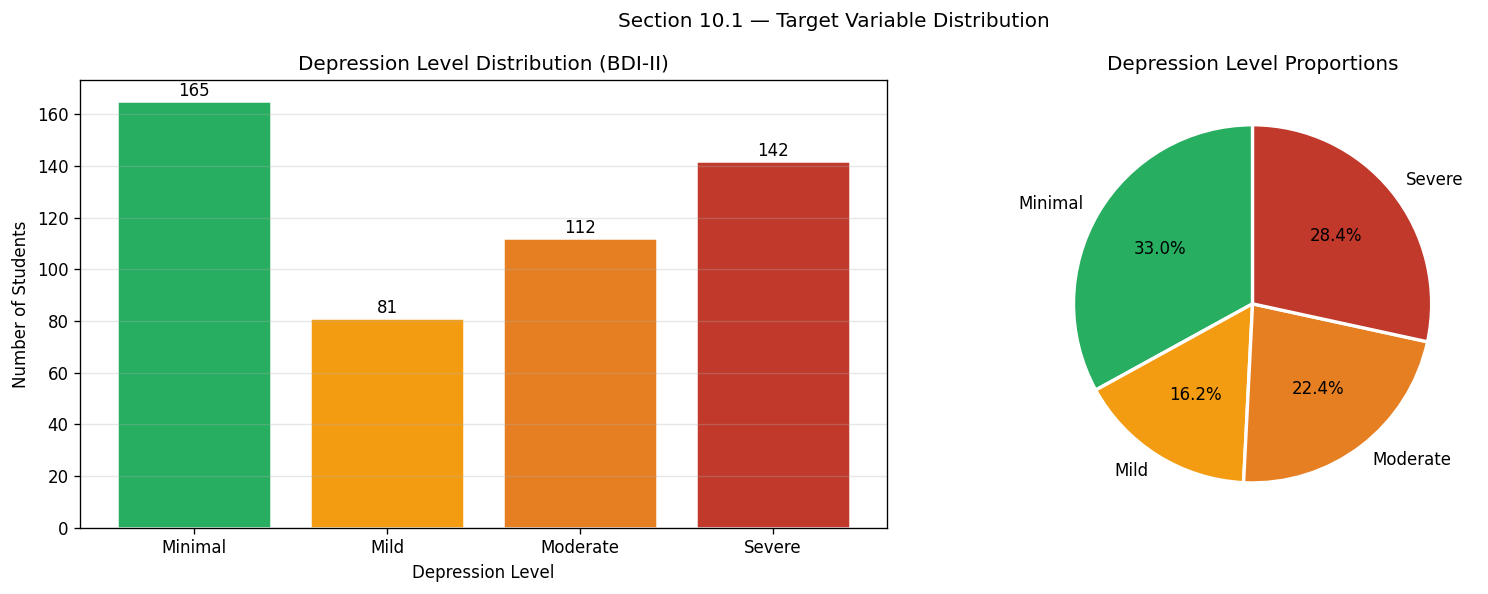

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors4 = ['#27ae60','#f39c12','#e67e22','#c0392b']

counts = df['Target_BDI'].value_counts().reindex(
 ['Minimal Depression','Mild Depression','Moderate Depression','Severe Depression'])
bars = axes[0].bar(CLASS_NAMES, counts.values, color=colors4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
 axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
 str(val), ha='center')
axes[0].set_title('Depression Level Distribution (BDI-II)')
axes[0].set_ylabel('Number of Students')
axes[0].set_xlabel('Depression Level')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(counts.values, labels=CLASS_NAMES, colors=colors4,
 autopct='%1.1f%%', startangle=90,
 wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Depression Level Proportions')

plt.suptitle('Section 10.1 — Target Variable Distribution', fontsize=12)
plt.tight_layout()
plt.savefig('viz_01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

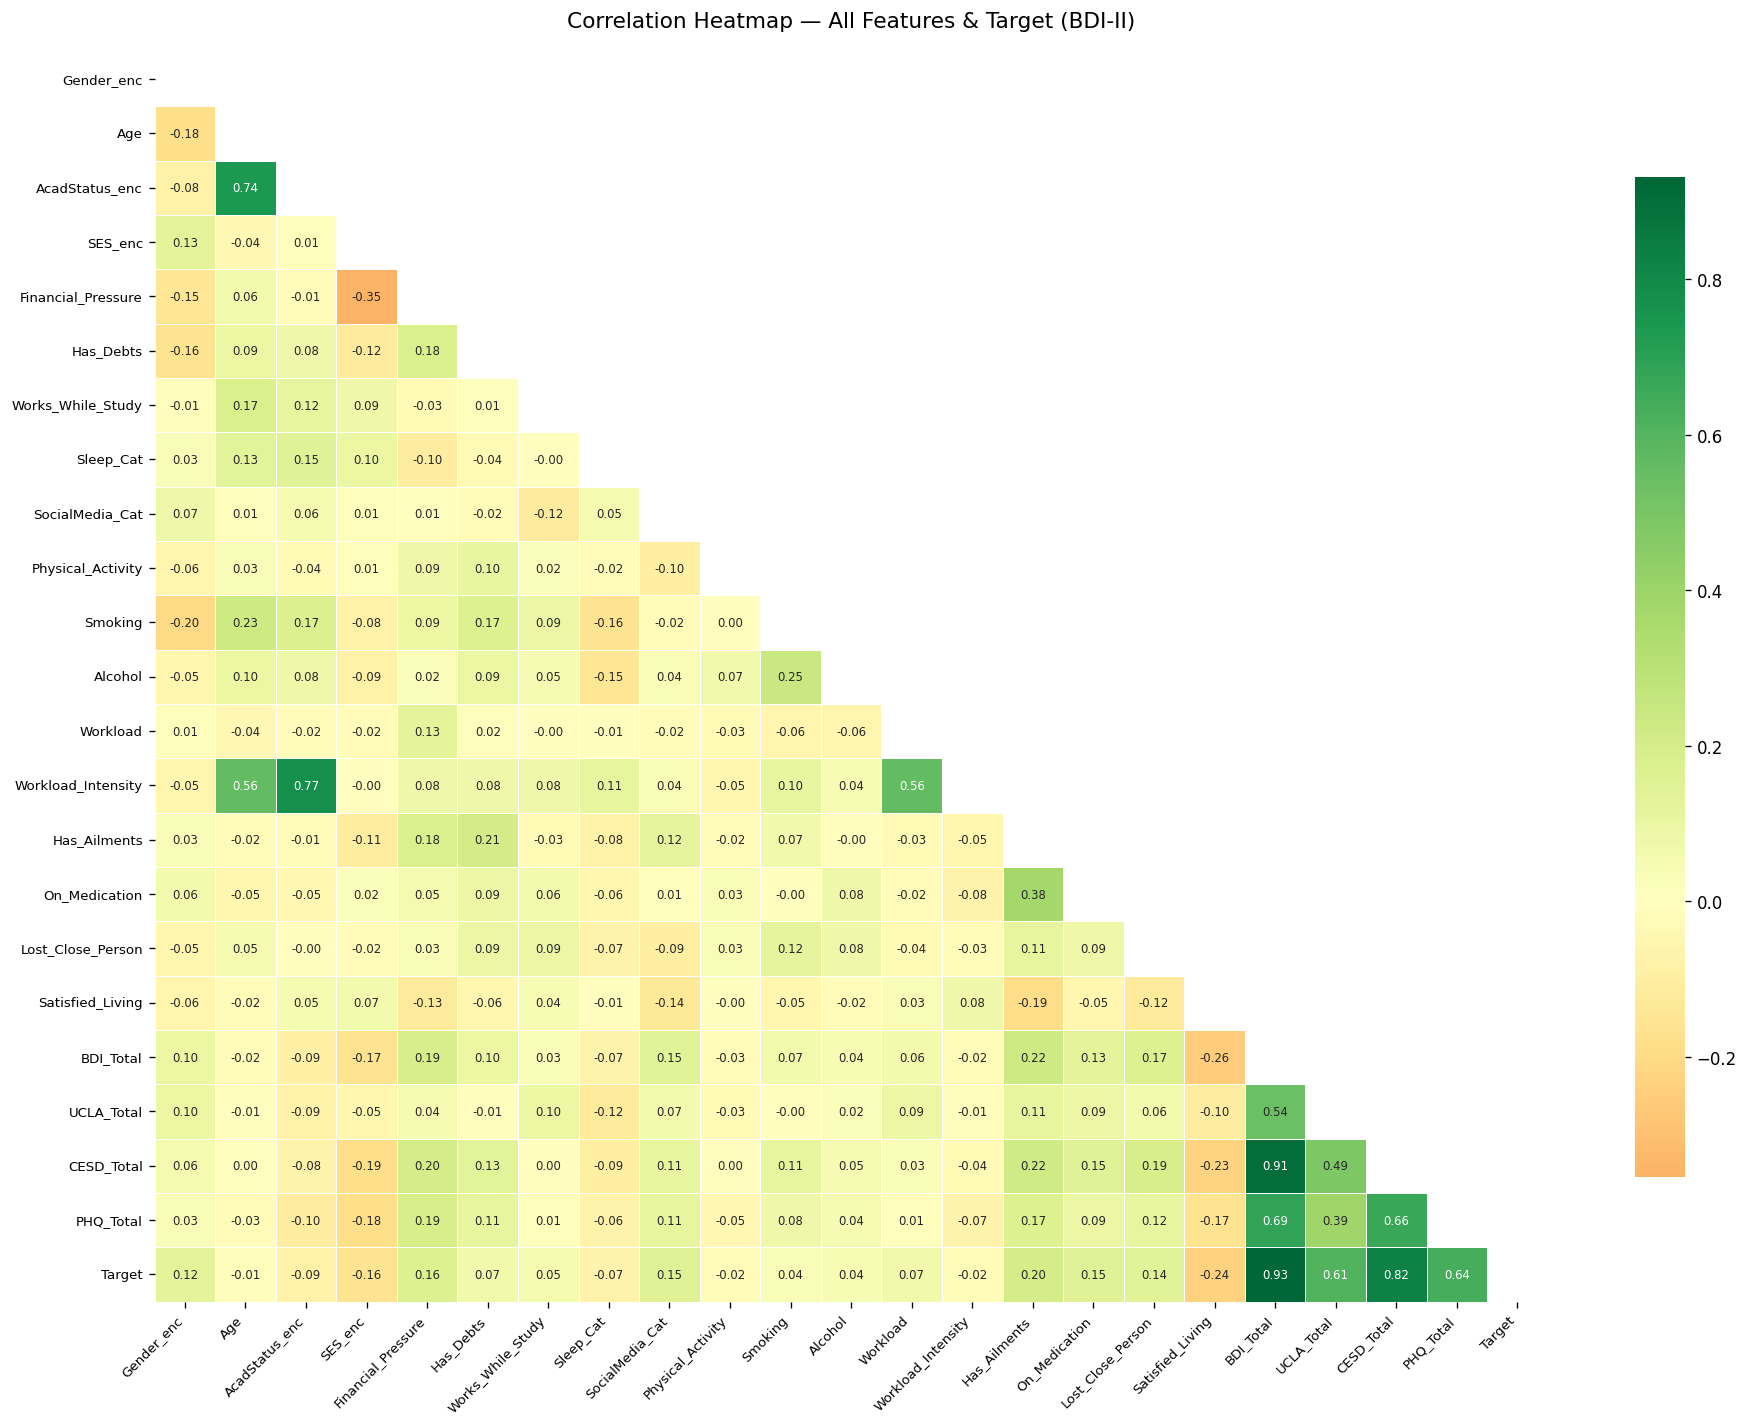

In [ ]:
numeric_for_corr = df[demo_feats + socioeco_feats + lifestyle_feats +
 behavioral_feats + composite_feats + ['Target']].copy()
corr_matrix = numeric_for_corr.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
 cmap='RdYlGn', center=0, square=False,
 linewidths=0.4, annot_kws={'size': 7},
 cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — All Features & Target (BDI-II)',
 fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('viz_02_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

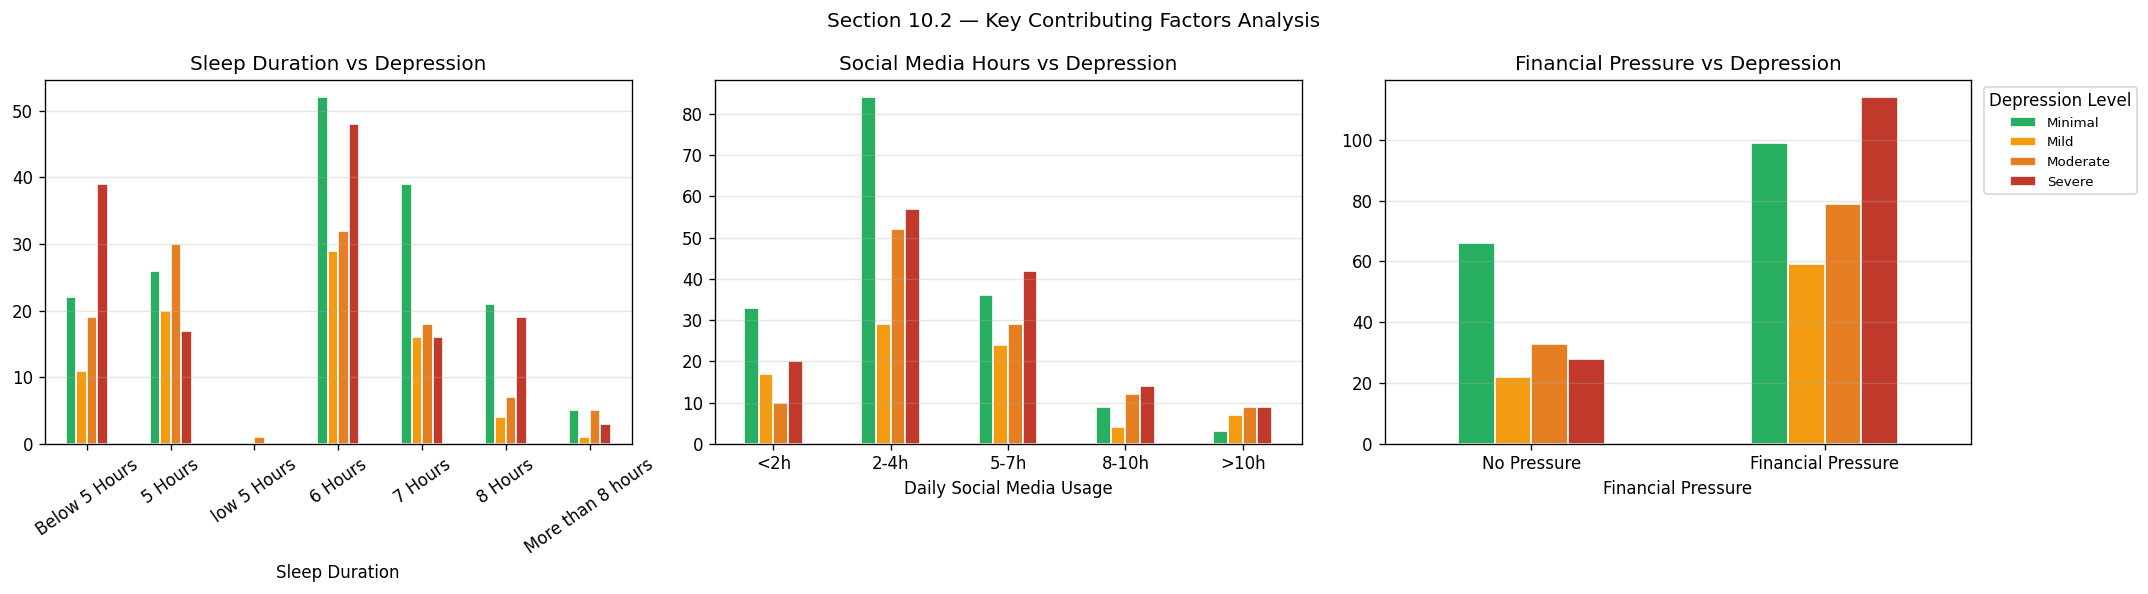

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sleep_order = ['Below 5 Hours','5 Hours','low 5 Hours','6 Hours','7 Hours','8 Hours','More than 8 hours']
sleep_order = [s for s in sleep_order if s in df['Sleep_Duration'].values]
sleep_dep = df.groupby(['Sleep_Duration','Target_BDI']).size().unstack(fill_value=0)
for col_name in ['Minimal Depression','Mild Depression','Moderate Depression','Severe Depression']:
    if col_name not in sleep_dep.columns:
        sleep_dep[col_name] = 0
sleep_dep = sleep_dep.reindex(index=sleep_order,
 columns=['Minimal Depression','Mild Depression','Moderate Depression','Severe Depression'])
sleep_dep.plot(kind='bar', ax=axes[0], color=colors4, edgecolor='white', legend=False)
axes[0].set_title('Sleep Duration vs Depression')
axes[0].set_xlabel('Sleep Duration')
axes[0].tick_params(axis='x', rotation=35)
axes[0].grid(axis='y', alpha=0.3)

sm_labels = ['<2h','2-4h','5-7h','8-10h','>10h']
df_sm = df.copy()
sm_dep = df_sm.groupby(['SocialMedia_Cat','Target']).size().unstack(fill_value=0)
sm_dep.index = [sm_labels[i] if i < len(sm_labels) else str(i) for i in sm_dep.index]
sm_dep.columns = CLASS_NAMES[:len(sm_dep.columns)]
sm_dep.plot(kind='bar', ax=axes[1], color=colors4, edgecolor='white', legend=False)
axes[1].set_title('Social Media Hours vs Depression')
axes[1].set_xlabel('Daily Social Media Usage')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

fp_dep = df.groupby(['Financial_Pressure','Target']).size().unstack(fill_value=0)
fp_dep.index = ['No Pressure', 'Financial Pressure']
fp_dep.columns = CLASS_NAMES[:len(fp_dep.columns)]
fp_dep.plot(kind='bar', ax=axes[2], color=colors4, edgecolor='white')
axes[2].set_title('Financial Pressure vs Depression')
axes[2].set_xlabel('Financial Pressure')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Depression Level', bbox_to_anchor=(1.01,1), fontsize=8)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Section 10.2 — Key Contributing Factors Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('viz_03_key_factors.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial', C=1.0),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42, class_weight='balanced',
        verbose=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=10, min_samples_leaf=5,
        random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=42, class_weight='balanced',
        n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, verbosity=0)
}

trained = {}
train_times = {}

print('Training models...')
for name, model in MODELS.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = round(time.time() - t0, 4)
    trained[name] = model
    train_times[name] = elapsed
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f'  {name:22s} — trained in {elapsed:.3f}s  | Test Accuracy: {acc:.4f}')

print('\nAll models trained successfully!')

Training models...
  Logistic Regression    — trained in 0.028s  | Test Accuracy: 0.8300
  LightGBM               — trained in 0.366s  | Test Accuracy: 0.9600
  Decision Tree          — trained in 0.005s  | Test Accuracy: 0.9600
  Random Forest          — trained in 0.662s  | Test Accuracy: 0.9500
  XGBoost                — trained in 0.326s  | Test Accuracy: 0.9500

All models trained successfully!


In [14]:
X_full = X_scaled
y_full = y

cv_results = {}
print('K-Fold Cross-Validation Results')
print('='*65)

for name, model in MODELS.items():
    # 5-fold
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores5 = cross_val_score(model, X_full, y_full, cv=cv5, scoring='accuracy', n_jobs=-1)
    # 10-fold
    cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores10 = cross_val_score(model, X_full, y_full, cv=cv10, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {'5fold_mean': scores5.mean(), '5fold_std': scores5.std(),
                        '10fold_mean': scores10.mean(), '10fold_std': scores10.std()}
    print(f'{name}')
    print(f'  5-Fold  CV: {scores5.mean():.4f} ± {scores5.std():.4f}  | Scores: {np.round(scores5,4)}')
    print(f'  10-Fold CV: {scores10.mean():.4f} ± {scores10.std():.4f}  | Scores: {np.round(scores10,4)}')
    print()

K-Fold Cross-Validation Results
Logistic Regression
  5-Fold  CV: 0.8480 ± 0.0248  | Scores: [0.86 0.85 0.8  0.86 0.87]
  10-Fold CV: 0.8720 ± 0.0475  | Scores: [0.88 0.9  0.88 0.86 0.74 0.9  0.88 0.86 0.9  0.92]

LightGBM
  5-Fold  CV: 0.9480 ± 0.0194  | Scores: [0.94 0.97 0.92 0.97 0.94]
  10-Fold CV: 0.9520 ± 0.0286  | Scores: [0.9  0.96 0.98 0.96 0.94 0.9  0.98 0.98 0.96 0.96]

Decision Tree
  5-Fold  CV: 0.9540 ± 0.0196  | Scores: [0.96 0.96 0.92 0.98 0.95]
  10-Fold CV: 0.9580 ± 0.0289  | Scores: [0.92 1.   0.98 0.96 0.94 0.9  0.98 0.98 0.96 0.96]

Random Forest
  5-Fold  CV: 0.9520 ± 0.0293  | Scores: [0.94 0.97 0.9  0.97 0.98]
  10-Fold CV: 0.9580 ± 0.0374  | Scores: [0.88 0.98 0.98 0.98 0.9  0.94 0.98 0.96 0.98 1.  ]

XGBoost
  5-Fold  CV: 0.9540 ± 0.0265  | Scores: [0.96 0.98 0.91 0.98 0.94]
  10-Fold CV: 0.9600 ± 0.0297  | Scores: [0.94 1.   0.98 0.98 0.92 0.9  0.98 0.98 0.96 0.96]



In [ ]:
def compute_all_metrics(name, model, X_tr, X_te, y_tr, y_te, train_t):
    res = {'Model': name}
    y_pred = model.predict(X_te)
    y_pred_tr = model.predict(X_tr)
    y_proba = model.predict_proba(X_te) if hasattr(model,'predict_proba') else None
    n = len(y_te)
    y_te_arr = np.array(y_te)

    res['Accuracy']            = round(accuracy_score(y_te, y_pred), 4)
    res['Balanced_Accuracy']   = round(balanced_accuracy_score(y_te, y_pred), 4)
    res['Precision_Weighted']  = round(precision_score(y_te, y_pred, average='weighted', zero_division=0), 4)
    res['Recall_Weighted']     = round(recall_score(y_te, y_pred, average='weighted', zero_division=0), 4)
    res['Specificity_avg']     = round(balanced_accuracy_score(y_te, y_pred), 4)  # proxy via balanced acc
    res['F1_Weighted']         = round(f1_score(y_te, y_pred, average='weighted', zero_division=0), 4)
    res['F2_Weighted']         = round(fbeta_score(y_te, y_pred, beta=2, average='weighted', zero_division=0), 4)
    res['F0_5_Weighted']       = round(fbeta_score(y_te, y_pred, beta=0.5, average='weighted', zero_division=0), 4)
    res['MCC']                 = round(matthews_corrcoef(y_te, y_pred), 4)
    res['Cohen_Kappa']         = round(cohen_kappa_score(y_te, y_pred), 4)

    if y_proba is not None:
        res['ROC_AUC_OvR_Weighted'] = round(roc_auc_score(y_te, y_proba, multi_class='ovr', average='weighted'), 4)
        res['ROC_AUC_OvR_Macro']    = round(roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro'), 4)

        pr_aucs = []
        for c in range(N_CLASSES):
            ap = average_precision_score((y_te_arr==c).astype(int), y_proba[:,c])
            pr_aucs.append(ap)
        res['PR_AUC_avg']        = round(np.mean(pr_aucs), 4)
        res['Log_Loss']          = round(log_loss(y_te, y_proba), 4)

        briers = [brier_score_loss((y_te_arr==c).astype(int), y_proba[:,c]) for c in range(N_CLASSES)]
        res['Brier_Score_avg']   = round(np.mean(briers), 4)
        res['Gini_Coefficient']  = round(2*res['ROC_AUC_OvR_Weighted'] - 1, 4)
    else:
        for k in ['ROC_AUC_OvR_Weighted','ROC_AUC_OvR_Macro','PR_AUC_avg','Log_Loss','Brier_Score_avg','Gini_Coefficient']:
            res[k] = np.nan

    res['Macro_Precision']  = round(precision_score(y_te, y_pred, average='macro', zero_division=0), 4)
    res['Macro_Recall']     = round(recall_score(y_te, y_pred, average='macro', zero_division=0), 4)
    res['Macro_F1']         = round(f1_score(y_te, y_pred, average='macro', zero_division=0), 4)
    res['Micro_Precision']  = round(precision_score(y_te, y_pred, average='micro', zero_division=0), 4)
    res['Micro_Recall']     = round(recall_score(y_te, y_pred, average='micro', zero_division=0), 4)
    res['Micro_F1']         = round(f1_score(y_te, y_pred, average='micro', zero_division=0), 4)

    cm = confusion_matrix(y_te, y_pred)
    tpr_l, tnr_l, fpr_l, fnr_l = [], [], [], []
    for c in range(N_CLASSES):
        TP = cm[c,c]
        FN = cm[c,:].sum() - TP
        FP = cm[:,c].sum() - TP
        TN = cm.sum() - TP - FP - FN
        tpr_l.append(TP/(TP+FN+1e-9))
        tnr_l.append(TN/(TN+FP+1e-9))
        fpr_l.append(FP/(FP+TN+1e-9))
        fnr_l.append(FN/(FN+TP+1e-9))
    res['Avg_TPR'] = round(np.mean(tpr_l), 4)
    res['Avg_TNR'] = round(np.mean(tnr_l), 4)
    res['Avg_FPR'] = round(np.mean(fpr_l), 4)
    res['Avg_FNR'] = round(np.mean(fnr_l), 4)

    if y_proba is not None:
        n_bins = 10
        ece_l, mce_l = [], []
        bins = np.linspace(0, 1, n_bins+1)
        for c in range(N_CLASSES):
            y_bin = (y_te_arr==c).astype(int)
            probs = y_proba[:,c]
            ece, mce = 0.0, 0.0
            for i in range(n_bins):
                mask = (probs>=bins[i]) & (probs<bins[i+1])
                if mask.sum()==0: continue
                gap = abs(y_bin[mask].mean() - probs[mask].mean())
                ece += (mask.sum()/n)*gap
                mce = max(mce, gap)
            ece_l.append(ece); mce_l.append(mce)
        res['ECE'] = round(np.mean(ece_l), 4)
        res['MCE'] = round(np.mean(mce_l), 4)
    else:
        res['ECE'] = res['MCE'] = np.nan

    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_sc = cross_val_score(model, X_full, y_full, cv=cv5, scoring='accuracy')
    res['CV5_Mean']         = round(cv_sc.mean(), 4)
    res['CV5_Std']          = round(cv_sc.std(), 4)
    res['Overfit_Gap']      = round(accuracy_score(y_tr, y_pred_tr) - res['Accuracy'], 4)

    res['Train_Time_s']     = train_t
    t0 = time.time()
    _ = model.predict(X_te)
    res['Inference_Time_s'] = round(time.time()-t0, 6)

    if hasattr(model, 'n_estimators'):
        res['Model_Complexity'] = model.n_estimators
    elif hasattr(model, 'tree_'):
        res['Model_Complexity'] = model.tree_.node_count
    else:
        try:
            res['Model_Complexity'] = sum(c.size for c in model.coef_)
        except:
            res['Model_Complexity'] = np.nan

    return res

print('Computing all metrics for all models...')
all_metrics = []
for name, model in trained.items():
    m = compute_all_metrics(name, model, X_train, X_test, y_train, y_test, train_times[name])
    all_metrics.append(m)
    print(f'  {name} done.')

metrics_df = pd.DataFrame(all_metrics).set_index('Model')
print('\n✅ All metrics computed.')

Computing all metrics for all models...
  Logistic Regression done.
  LightGBM done.
  Decision Tree done.
  Random Forest done.
  XGBoost done.

✅ All metrics computed.


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print('═'*70)
print('8.1  CLASSIFICATION METRICS')
print('═'*70)
print(metrics_df[['Accuracy','Balanced_Accuracy','Precision_Weighted',
                   'Recall_Weighted','F1_Weighted','F2_Weighted',
                   'F0_5_Weighted','MCC','Cohen_Kappa']].T.to_string())

print('\n'+'═'*70)
print('8.2  PROBABILITY & RANKING METRICS')
print('═'*70)
print(metrics_df[['ROC_AUC_OvR_Weighted','ROC_AUC_OvR_Macro',
                   'PR_AUC_avg','Log_Loss','Brier_Score_avg','Gini_Coefficient']].T.to_string())

print('\n'+'═'*70)
print('8.3  MULTI-CLASS METRICS')
print('═'*70)
print(metrics_df[['Macro_Precision','Macro_Recall','Macro_F1',
                   'Micro_Precision','Micro_Recall','Micro_F1','F1_Weighted']].T.to_string())

print('\n'+'═'*70)
print('8.4  CONFUSION MATRIX METRICS')
print('═'*70)
print(metrics_df[['Avg_TPR','Avg_TNR','Avg_FPR','Avg_FNR']].T.to_string())

print('\n'+'═'*70)
print('8.5  CALIBRATION METRICS (ECE / MCE)')
print('═'*70)
print(metrics_df[['ECE','MCE']].T.to_string())

print('\n'+'═'*70)
print('8.7  MODEL STABILITY METRICS')
print('═'*70)
print(metrics_df[['CV5_Mean','CV5_Std','Overfit_Gap']].T.to_string())

print('\n'+'═'*70)
print('8.10 COMPUTATIONAL METRICS')
print('═'*70)
print(metrics_df[['Train_Time_s','Inference_Time_s','Model_Complexity']].T.to_string())

══════════════════════════════════════════════════════════════════════
8.1  CLASSIFICATION METRICS
══════════════════════════════════════════════════════════════════════
Model               Logistic Regression  LightGBM  Decision Tree  Random Forest  XGBoost
Accuracy                         0.8300    0.9600         0.9600         0.9500   0.9500
Balanced_Accuracy                0.8239    0.9460         0.9558         0.9359   0.9304
Precision_Weighted               0.8552    0.9595         0.9625         0.9564   0.9496
Recall_Weighted                  0.8300    0.9600         0.9600         0.9500   0.9500
F1_Weighted                      0.8375    0.9593         0.9605         0.9498   0.9487
F2_Weighted                      0.8317    0.9596         0.9600         0.9491   0.9492
F0_5_Weighted                    0.8470    0.9593         0.9615         0.9530   0.9489
MCC                              0.7744    0.9455         0.9460         0.9336   0.9321
Cohen_Kappa                  

In [ ]:
print('═'*70)
print('8.8  FAIRNESS METRICS — Demographic Parity, Equal Opportunity, Disparate Impact')
print('═'*70)

test_idx = y_test.index
gender_test = df.loc[test_idx, 'Gender_enc'].values

fairness_rows = []
for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_te_arr = np.array(y_test)
    pos_pred = (y_pred >= 2).astype(int)
    pos_true = (y_te_arr >= 2).astype(int)

    groups = np.unique(gender_test)
    rates, tpr_g = {}, {}
    for g in groups:
        gm = gender_test == g
        rates[g] = pos_pred[gm].mean()
        true_pos = (pos_true[gm] == 1)
        tpr_g[g] = pos_pred[gm][true_pos].mean() if true_pos.sum() > 0 else 0

    dpd = round(max(rates.values()) - min(rates.values()), 4)
    eod = round(max(tpr_g.values()) - min(tpr_g.values()), 4)
    dir_ = round(min(rates.values()) / (max(rates.values()) + 1e-9), 4) if max(rates.values()) > 0 else 1.0
    fairness_rows.append({'Model':name, 'Demographic_Parity_Diff':dpd,
                           'Equal_Opportunity_Diff':eod, 'Disparate_Impact_Ratio':dir_})

fair_df = pd.DataFrame(fairness_rows).set_index('Model')
print(fair_df.to_string())
print('\n(Closer to 0 for DPD/EOD = more fair; closer to 1 for DIR = more fair)')

══════════════════════════════════════════════════════════════════════
8.8  FAIRNESS METRICS — Demographic Parity, Equal Opportunity, Disparate Impact
══════════════════════════════════════════════════════════════════════
                     Demographic_Parity_Diff  Equal_Opportunity_Diff  Disparate_Impact_Ratio
Model                                                                                       
Logistic Regression                   0.2349                  0.0588                  0.6407
LightGBM                              0.2464                  0.0294                  0.6441
Decision Tree                         0.2464                  0.0294                  0.6441
Random Forest                         0.2193                  0.0000                  0.6832
XGBoost                               0.2464                  0.0294                  0.6441

(Closer to 0 for DPD/EOD = more fair; closer to 1 for DIR = more fair)


In [ ]:
print('═'*70)
print('8.9  STATISTICAL METRICS — p-values, Confidence Intervals, Cohen\'s d')
print('═'*70)

stat_features = [
    ('BDI_Total', 'BDI Total Score'),
    ('UCLA_Total', 'UCLA Loneliness Score'),
    ('Sleep_Cat', 'Sleep Category'),
    ('SocialMedia_Cat', 'Social Media Usage'),
    ('Financial_Pressure', 'Financial Pressure'),
    ('CESD_Total', 'CES-D Total Score'),
    ('Age', 'Age')
]

stat_rows = []
for feat, label in stat_features:
    if feat not in df.columns: continue
    sev = df.loc[df['Target']==3, feat].dropna()
    non_sev = df.loc[df['Target']<3, feat].dropna()
    t_stat, p_val = stats.ttest_ind(sev, non_sev, equal_var=False)  # Welch's t-test
    mean_diff = sev.mean() - non_sev.mean()
    pooled_std = np.sqrt((sev.std()**2 + non_sev.std()**2) / 2)
    cohens_d = mean_diff / (pooled_std + 1e-9)
    se = np.sqrt(sev.var()/len(sev) + non_sev.var()/len(non_sev))
    ci_low, ci_high = mean_diff - 1.96*se, mean_diff + 1.96*se
    stat_rows.append({
        'Feature': label,
        'Mean_Severe': round(sev.mean(),3),
        'Mean_NonSevere': round(non_sev.mean(),3),
        'p_value': round(p_val, 6),
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        "Cohen's_d": round(cohens_d, 4),
        'Effect_Size': 'Large' if abs(cohens_d)>=0.8 else ('Medium' if abs(cohens_d)>=0.5 else 'Small'),
        '95%CI': f'[{ci_low:.3f}, {ci_high:.3f}]'
    })

stat_df = pd.DataFrame(stat_rows)
print(stat_df.to_string(index=False))

══════════════════════════════════════════════════════════════════════
8.9  STATISTICAL METRICS — p-values, Confidence Intervals, Cohen's d
══════════════════════════════════════════════════════════════════════
              Feature  Mean_Severe  Mean_NonSevere  p_value Significant  Cohen's_d Effect_Size            95%CI
      BDI Total Score      38.8870         13.9390   0.0000         Yes     3.3853       Large [23.551, 26.347]
UCLA Loneliness Score      20.0420         15.9580   0.0000         Yes     0.8218       Large   [3.146, 5.022]
       Sleep Category       0.7610          0.7600   0.9908          No     0.0012       Small  [-0.133, 0.135]
   Social Media Usage       1.5420          1.3800   0.1184          No     0.1567       Small  [-0.041, 0.365]
   Financial Pressure       0.8030          0.6620   0.0009         Yes     0.3214       Small   [0.059, 0.223]
    CES-D Total Score      15.2250          5.2040   0.0000         Yes     2.2495       Large  [9.100, 10.943]
     

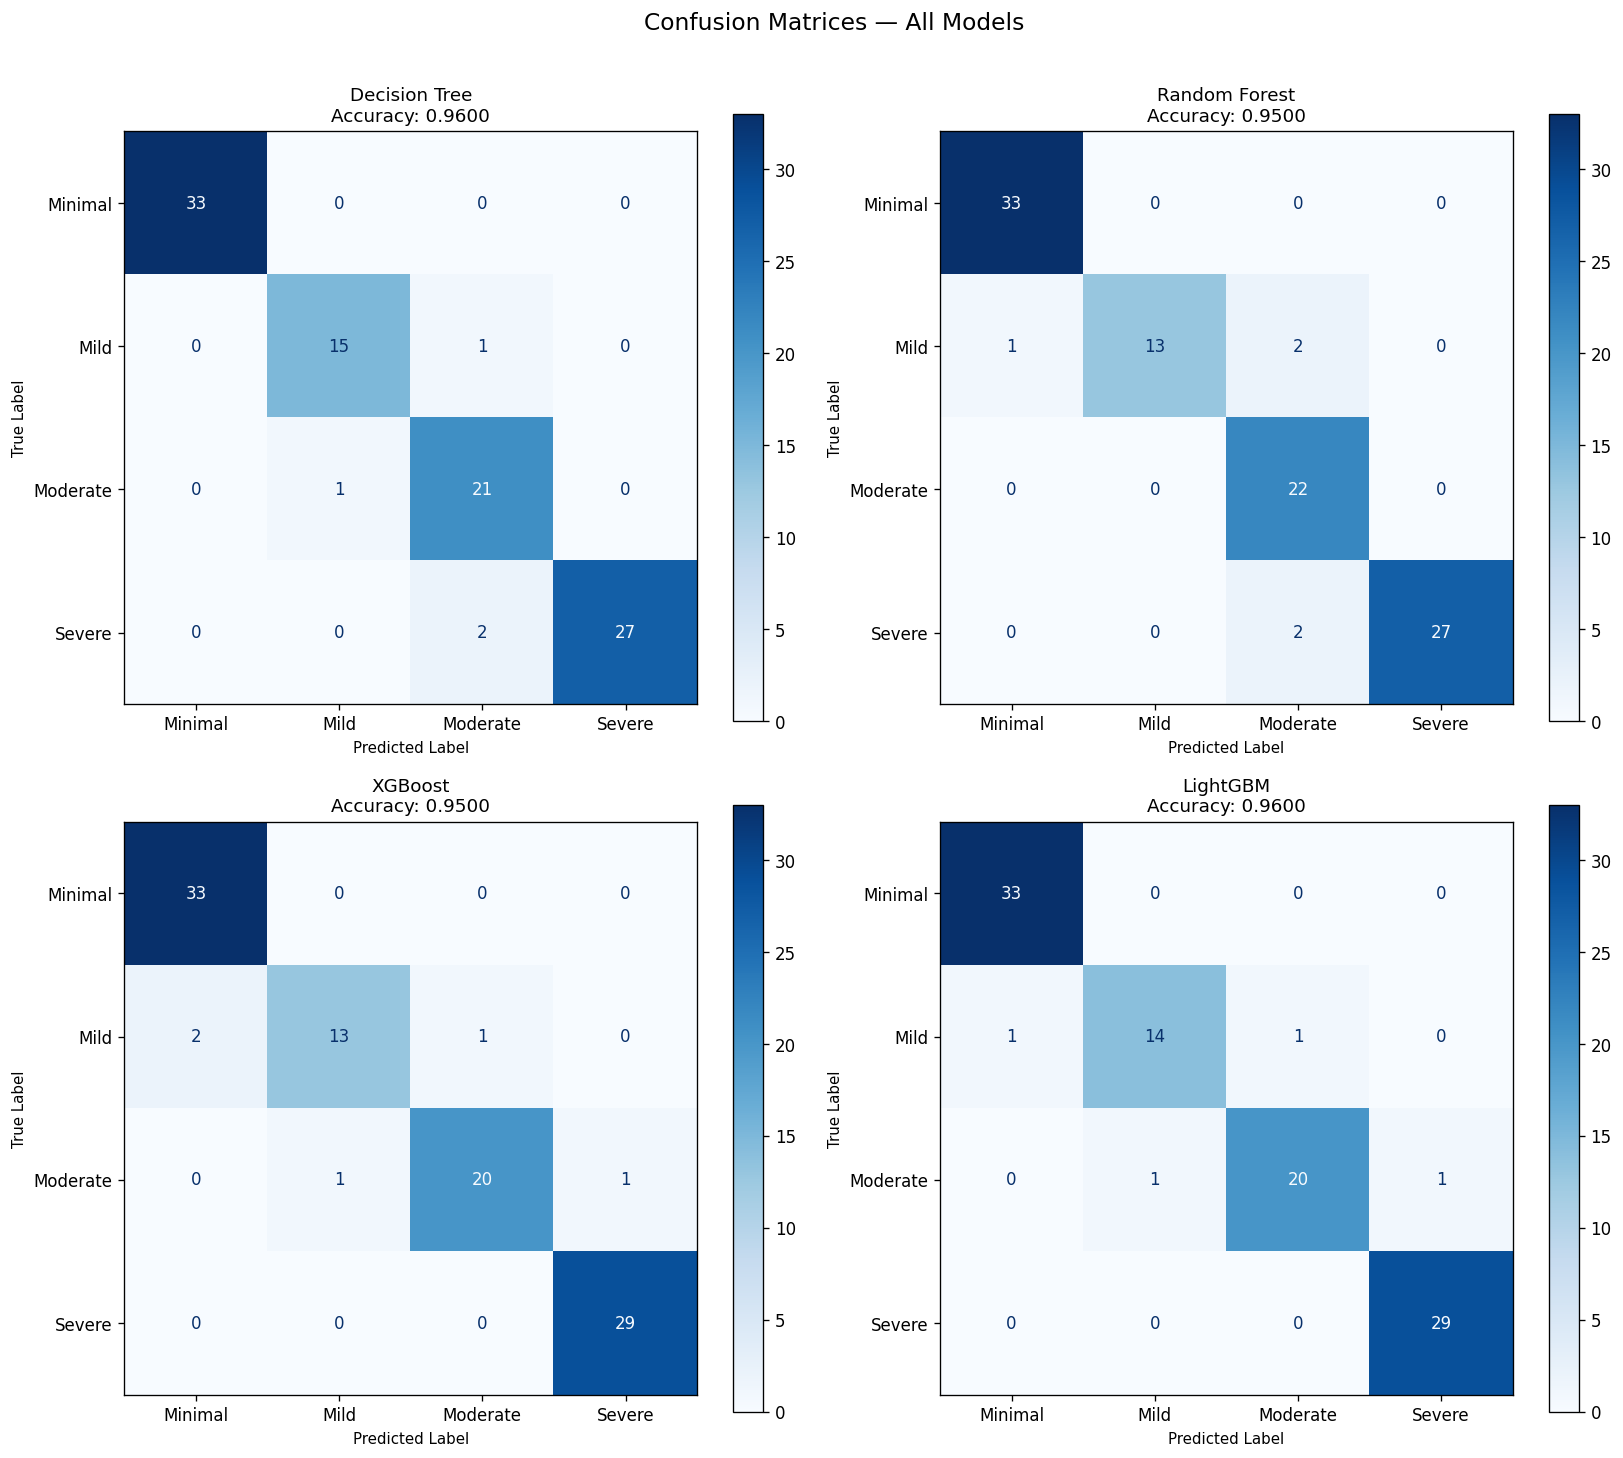

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

selected_models = {
    'Decision Tree': trained['Decision Tree'],
    'Random Forest': trained['Random Forest'],
    'XGBoost':       trained['XGBoost'],
    'LightGBM':      trained['LightGBM'],
}

CLASS_NAMES = ['Minimal', 'Mild', 'Moderate', 'Severe']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, selected_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=True)

    ax.set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label',      fontsize=9)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_04_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

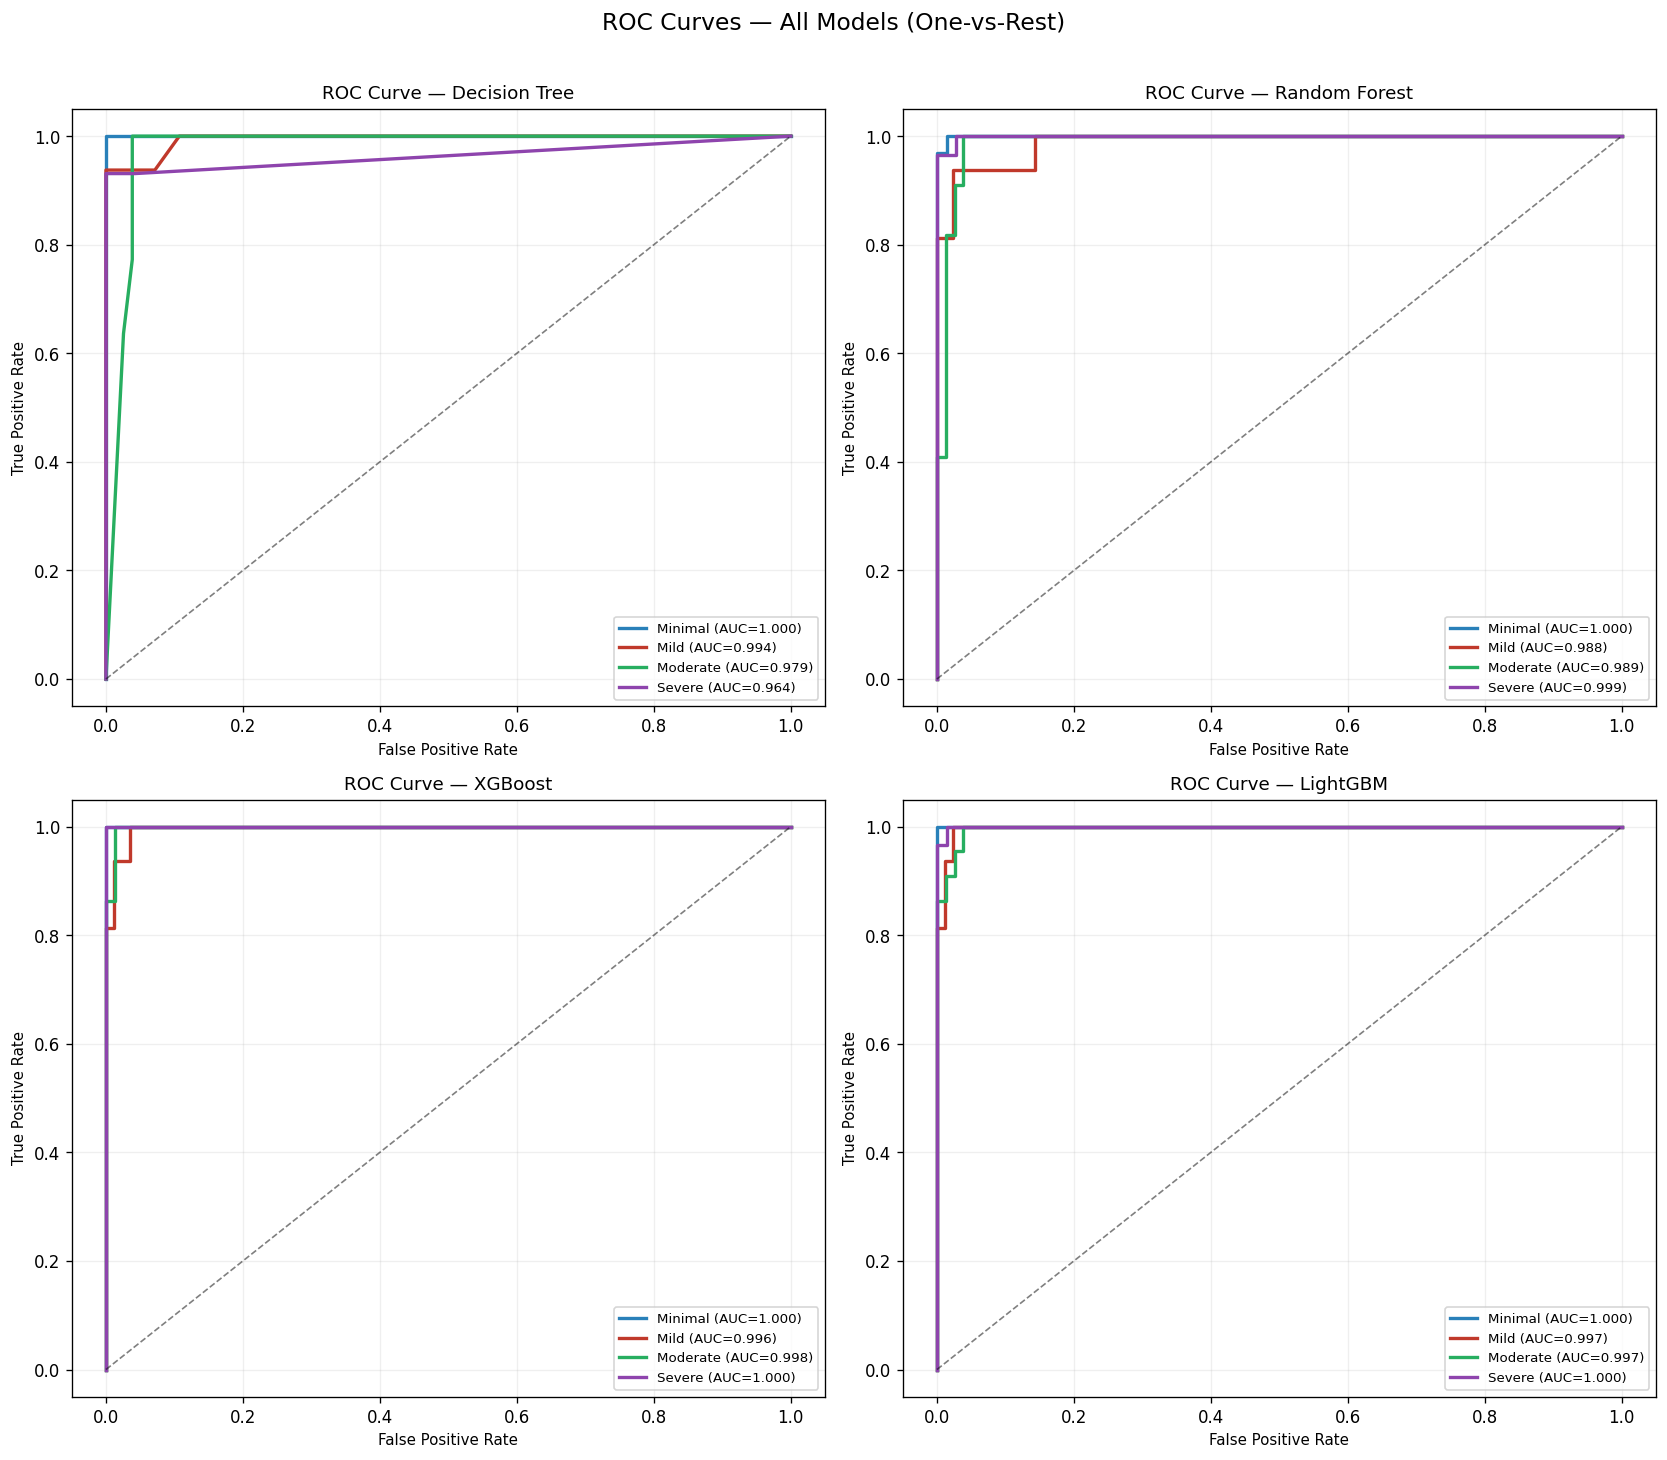

In [ ]:
import matplotlib.pyplot as plt

selected_models = {k: trained[k] for k in
                   ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']}

CLASS_NAMES = ['Minimal', 'Mild', 'Moderate', 'Severe']
line_colors = ['#2980b9', '#c0392b', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, selected_models.items()):
    y_proba = model.predict_proba(X_test)
    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, line_colors)):
        fpr, tpr, _ = roc_curve(
            (np.array(y_test) == i).astype(int), y_proba[:, i])
        auc = roc_auc_score(
            (np.array(y_test) == i).astype(int), y_proba[:, i])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'ROC Curve — {name}', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('ROC Curves — All Models (One-vs-Rest)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_05_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

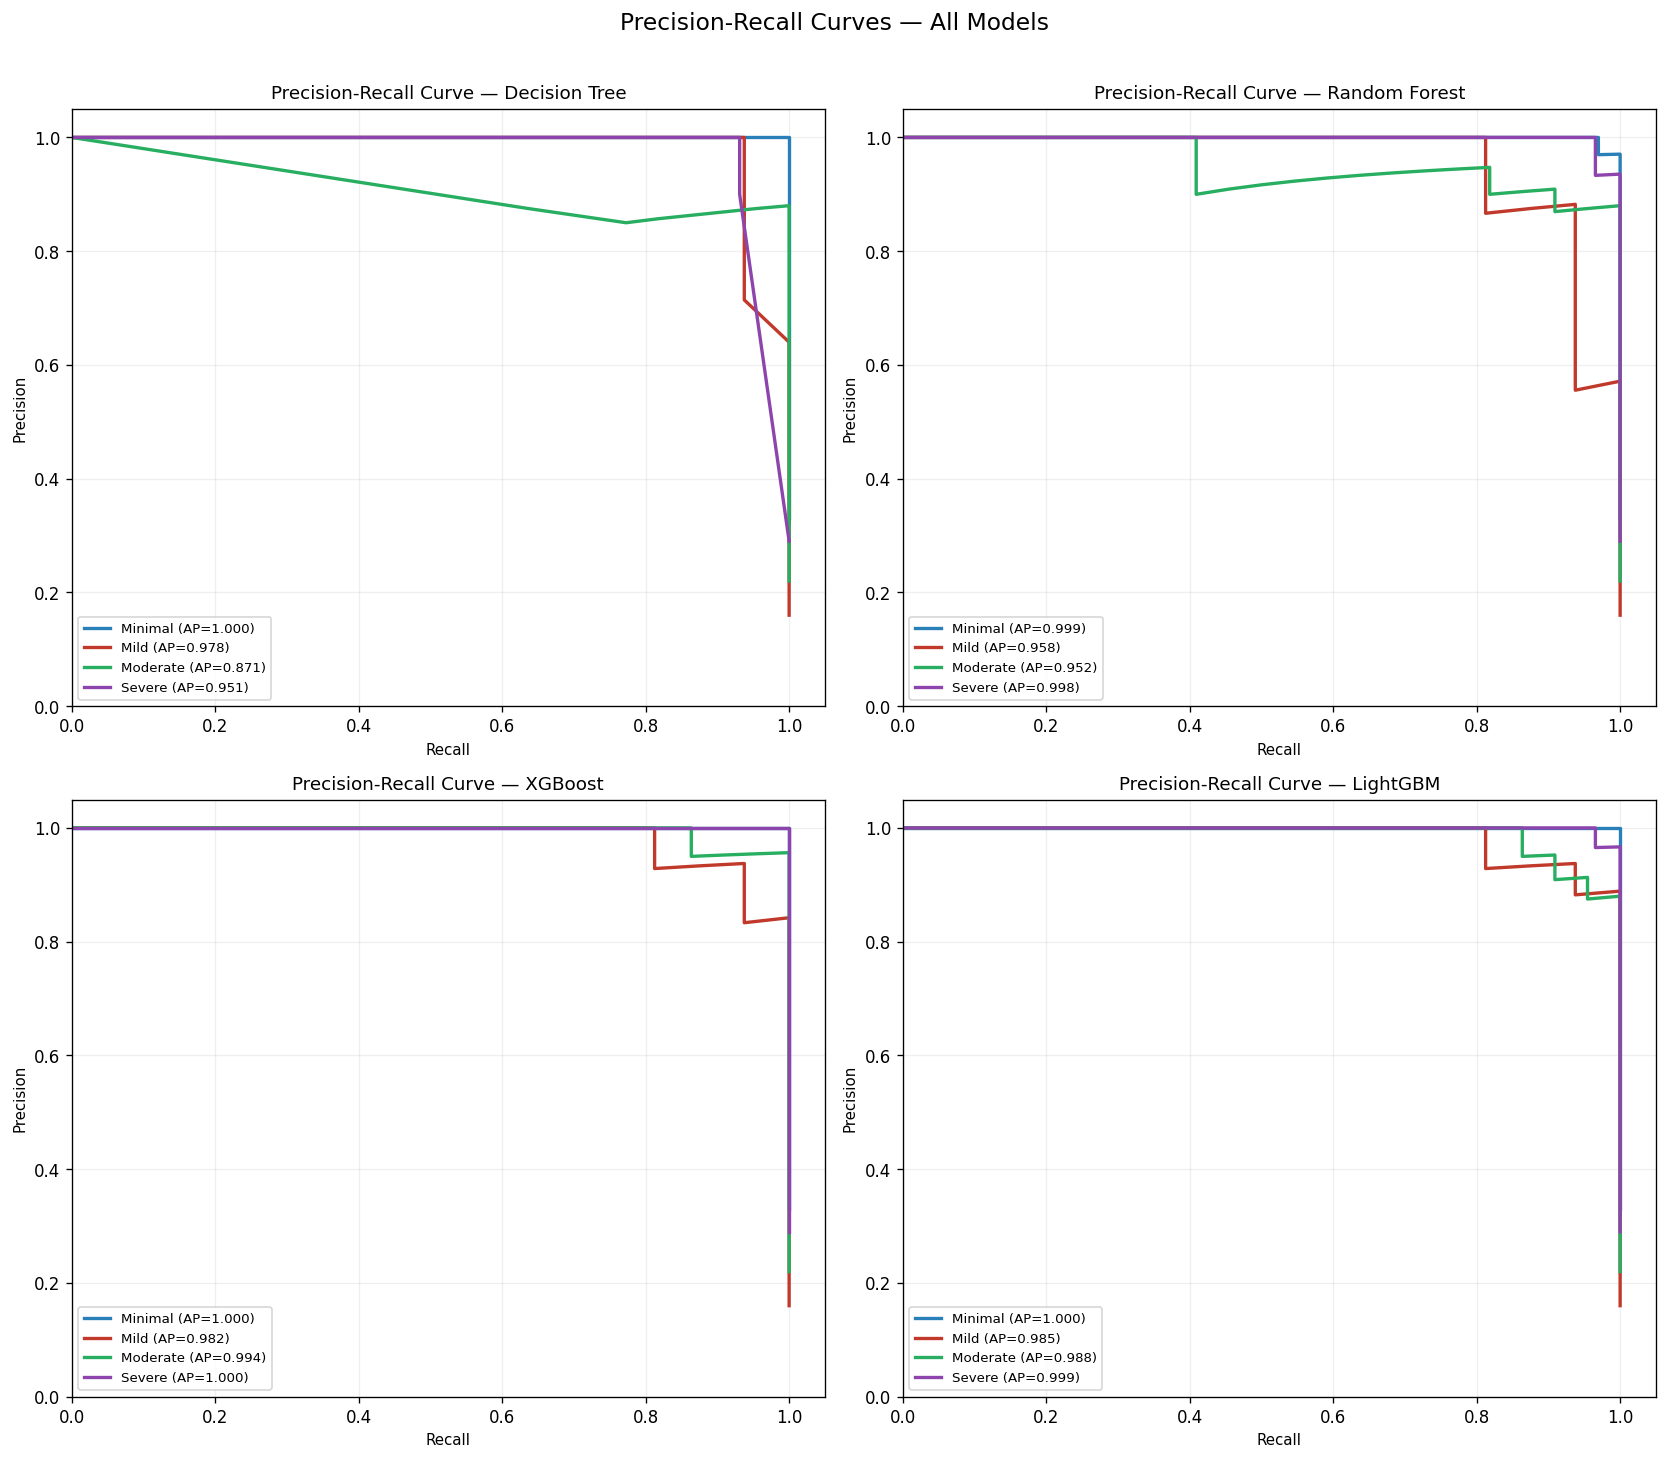

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

selected_models = {
    'Decision Tree': trained['Decision Tree'],
    'Random Forest': trained['Random Forest'],
    'XGBoost':       trained['XGBoost'],
    'LightGBM':      trained['LightGBM'],
}

CLASS_NAMES = ['Minimal', 'Mild', 'Moderate', 'Severe']
line_colors = ['#2980b9', '#c0392b', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, selected_models.items()):

    y_proba = model.predict_proba(X_test)

    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, line_colors)):
        y_bin = (np.array(y_test) == i).astype(int)

        prec, rec, _ = precision_recall_curve(y_bin, y_proba[:, i])
        ap            = average_precision_score(y_bin, y_proba[:, i])

        ax.plot(rec, prec, color=color, lw=2,
                label=f'{cls_name} (AP={ap:.3f})')

    ax.set_xlabel('Recall',    fontsize=9)
    ax.set_ylabel('Precision', fontsize=9)
    ax.set_title(f'Precision-Recall Curve — {name}', fontsize=11)
    ax.legend(loc='lower left', fontsize=8)   # ← changed here
    ax.grid(alpha=0.2)
    ax.set_xlim([0.0, 1.05])
    ax.set_ylim([0.0, 1.05])

plt.suptitle('Precision-Recall Curves — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_06_precision_recall_curves.png', bbox_inches='tight', dpi=150)
plt.show()

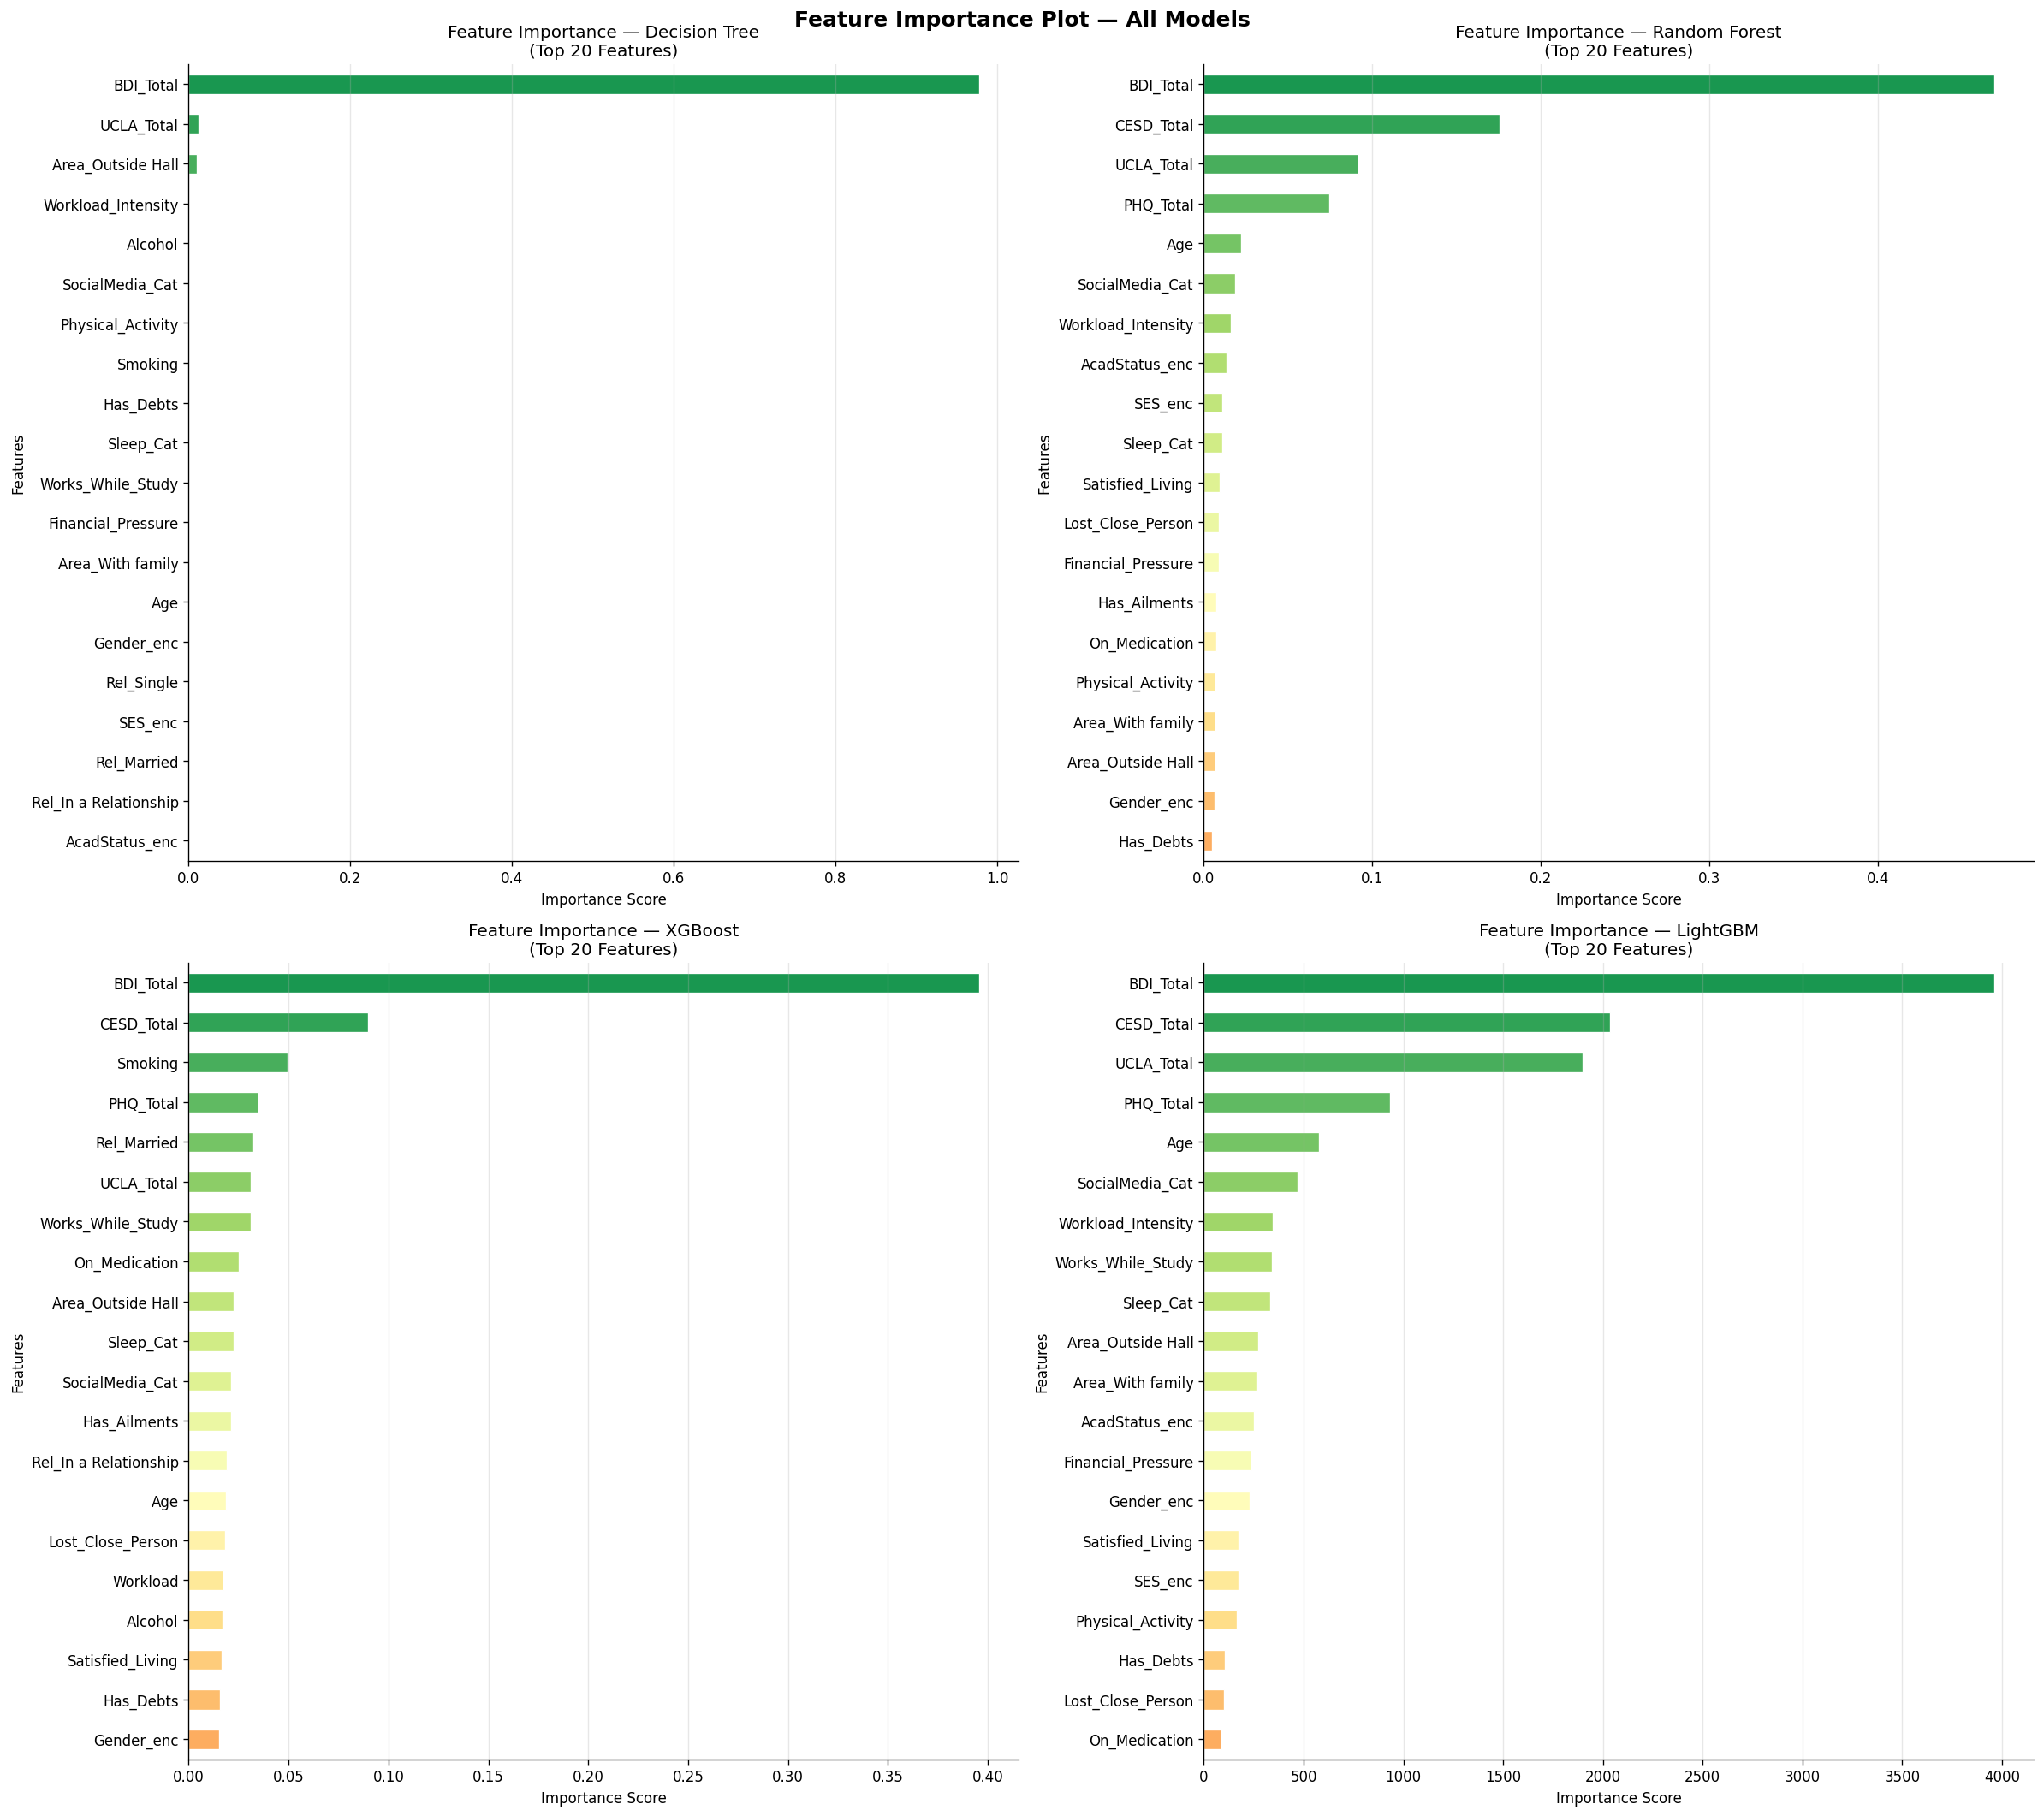

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

selected_models = {
    'Decision Tree': trained['Decision Tree'],
    'Random Forest': trained['Random Forest'],
    'XGBoost':       trained['XGBoost'],
    'LightGBM':      trained['LightGBM'],
}

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
axes = axes.flatten()

for ax, (name, model) in zip(axes, selected_models.items()):

    importances = model.feature_importances_
    feat_imp    = pd.Series(importances, index=ALL_FEATURES).sort_values(ascending=False)
    top20       = feat_imp.head(20).sort_values()   # ascending for barh

    colors_imp  = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))

    top20.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white', linewidth=0.8)

    ax.set_title(f'Feature Importance — {name}\n(Top 20 Features)', fontsize=12)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.set_ylabel('Features',         fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Importance Plot — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_feature_importance_all.png', bbox_inches='tight', dpi=150)
plt.show()

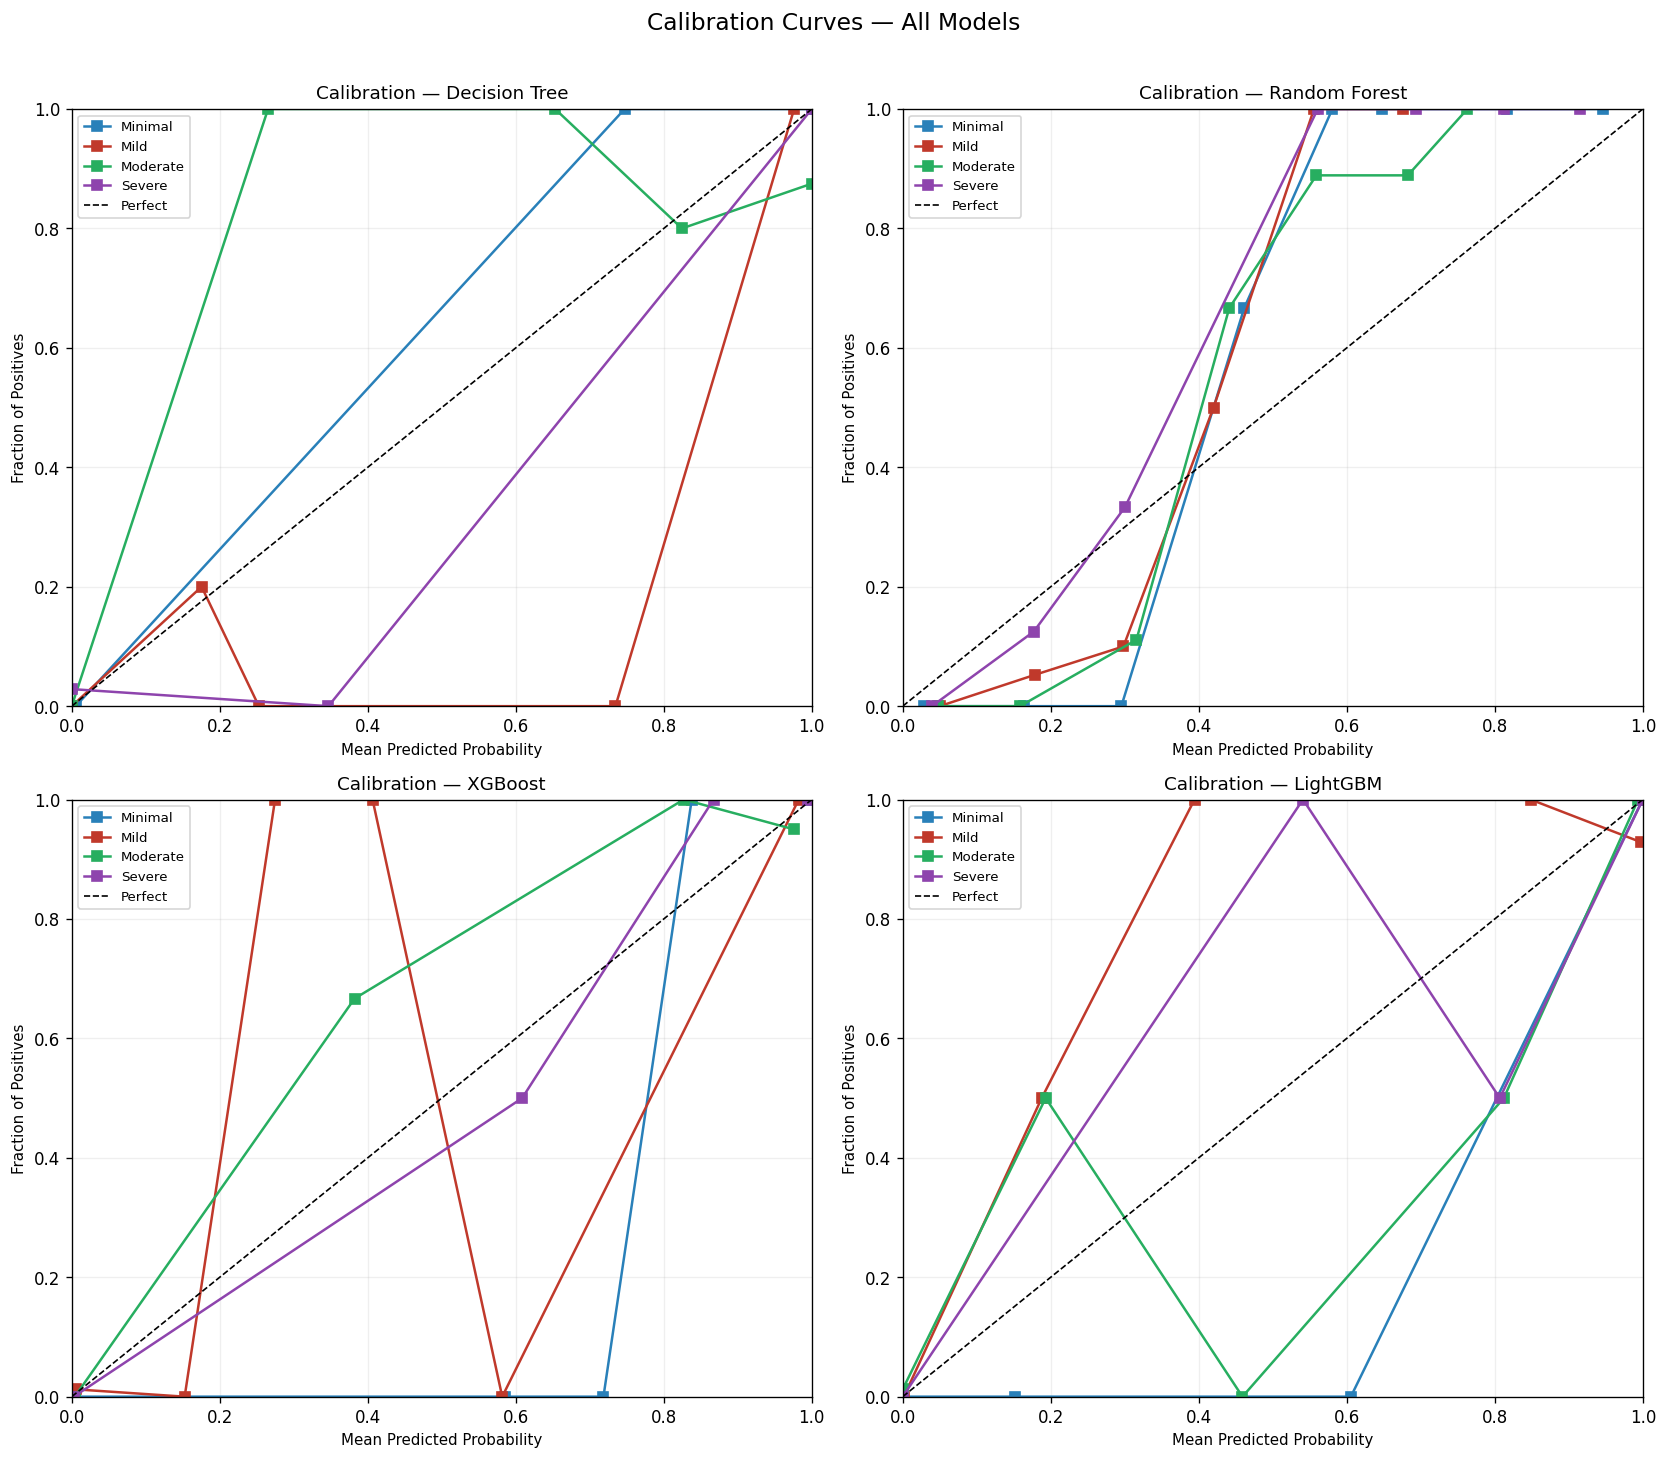

In [ ]:

from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

selected_models = {
    'Decision Tree': trained['Decision Tree'],
    'Random Forest': trained['Random Forest'],
    'XGBoost':       trained['XGBoost'],
    'LightGBM':      trained['LightGBM'],
}


CLASS_NAMES = ['Minimal', 'Mild', 'Moderate', 'Severe']
line_colors = ['#2980b9', '#c0392b', '#27ae60', '#8e44ad']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, selected_models.items()):

    y_proba = model.predict_proba(X_test)   # shape: (n_samples, 4)

    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, line_colors)):
        y_bin = (np.array(y_test) == i).astype(int)

        prob_true, prob_pred = calibration_curve(
            y_bin, y_proba[:, i],
            n_bins=8, strategy='uniform'
        )

        ax.plot(prob_pred, prob_true, 's-', color=color,
                lw=1.5, label=cls_name)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')

    ax.set_xlabel('Mean Predicted Probability', fontsize=9)
    ax.set_ylabel('Fraction of Positives',      fontsize=9)
    ax.set_title(f'Calibration — {name}',       fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])

plt.suptitle('Calibration Curves — All Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('viz_08_calibration_curves.png', bbox_inches='tight', dpi=150)
plt.show()

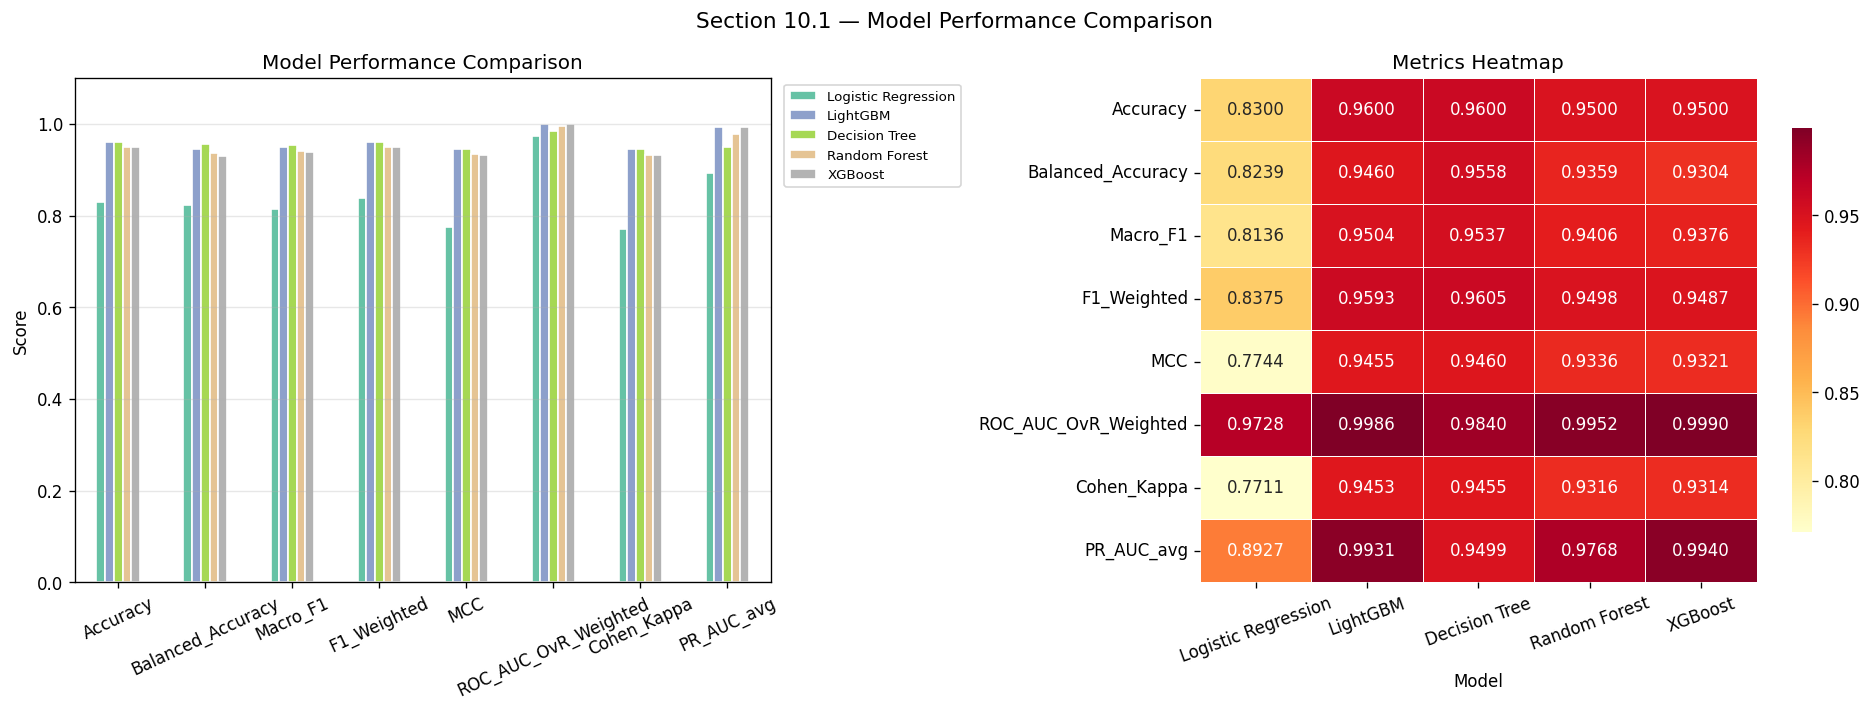

In [ ]:
key_cols = ['Accuracy','Balanced_Accuracy','Macro_F1','F1_Weighted','MCC',
 'ROC_AUC_OvR_Weighted','Cohen_Kappa','PR_AUC_avg']
cmp = metrics_df[key_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmp.T.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Model Performance Comparison')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(bbox_to_anchor=(1.01,1), fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

sns.heatmap(cmp.T, annot=True, fmt='.4f', cmap='YlOrRd',
 ax=axes[1], linewidths=0.5, cbar_kws={'shrink':0.8})
axes[1].set_title('Metrics Heatmap')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Section 10.1 — Model Performance Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('viz_09_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
rf_model = trained['Random Forest']
xgb_model = trained['XGBoost']

print('Computing SHAP values for Random Forest...')
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
print('RF SHAP done.')

print('Computing SHAP values for XGBoost...')
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)
print('XGB SHAP done.')

Computing SHAP values for Random Forest...
RF SHAP done.
Computing SHAP values for XGBoost...
XGB SHAP done.


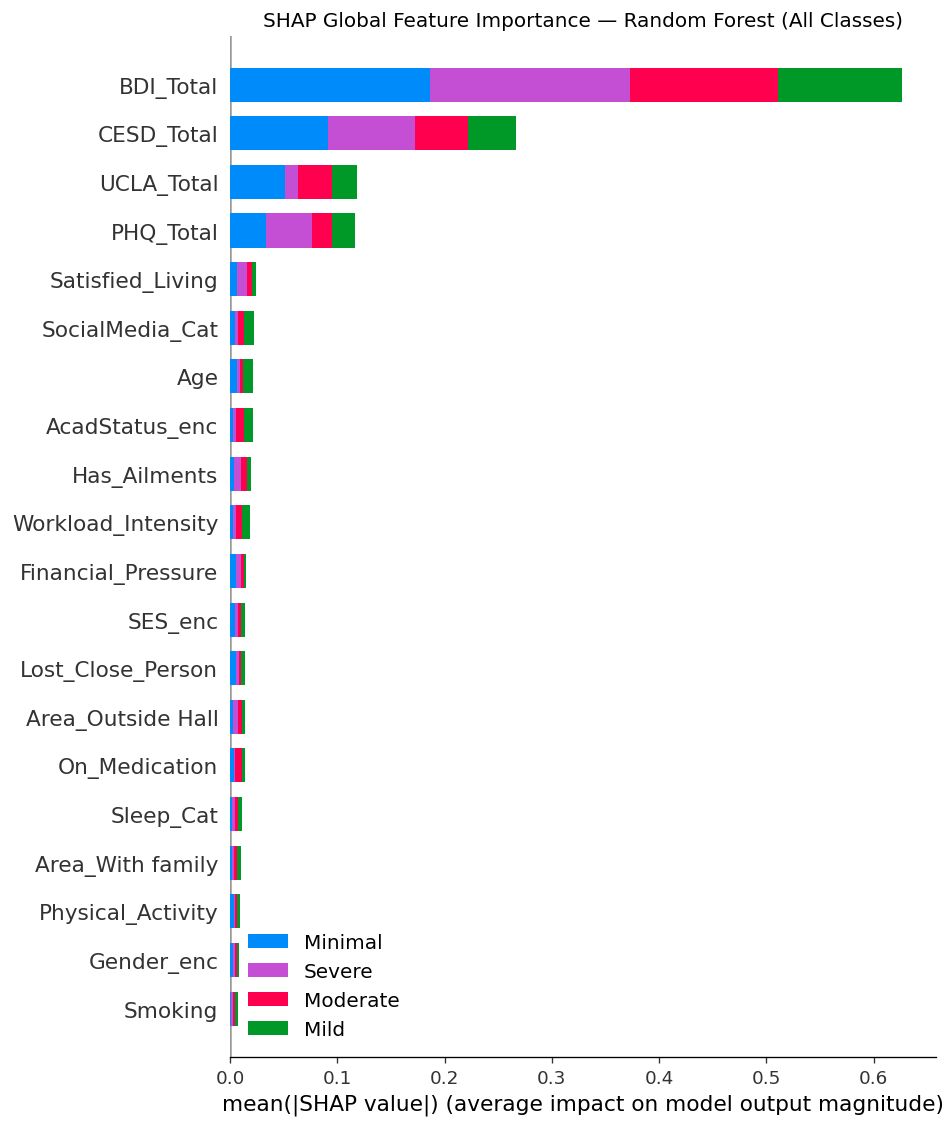

In [ ]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_rf, X_test, plot_type='bar',
 class_names=CLASS_NAMES, feature_names=ALL_FEATURES,
 show=False, max_display=20)
plt.title('SHAP Global Feature Importance — Random Forest (All Classes)',
 fontsize=12)
plt.tight_layout()
plt.savefig('viz_10_shap_global_bar.png', bbox_inches='tight', dpi=150)
plt.show()

Shape of X_test: (100, 27)
Type of shap_values_rf: <class 'numpy.ndarray'>
Shape of shap_values_rf: (100, 27, 4)
Shape of shap_values_class: (100, 27)


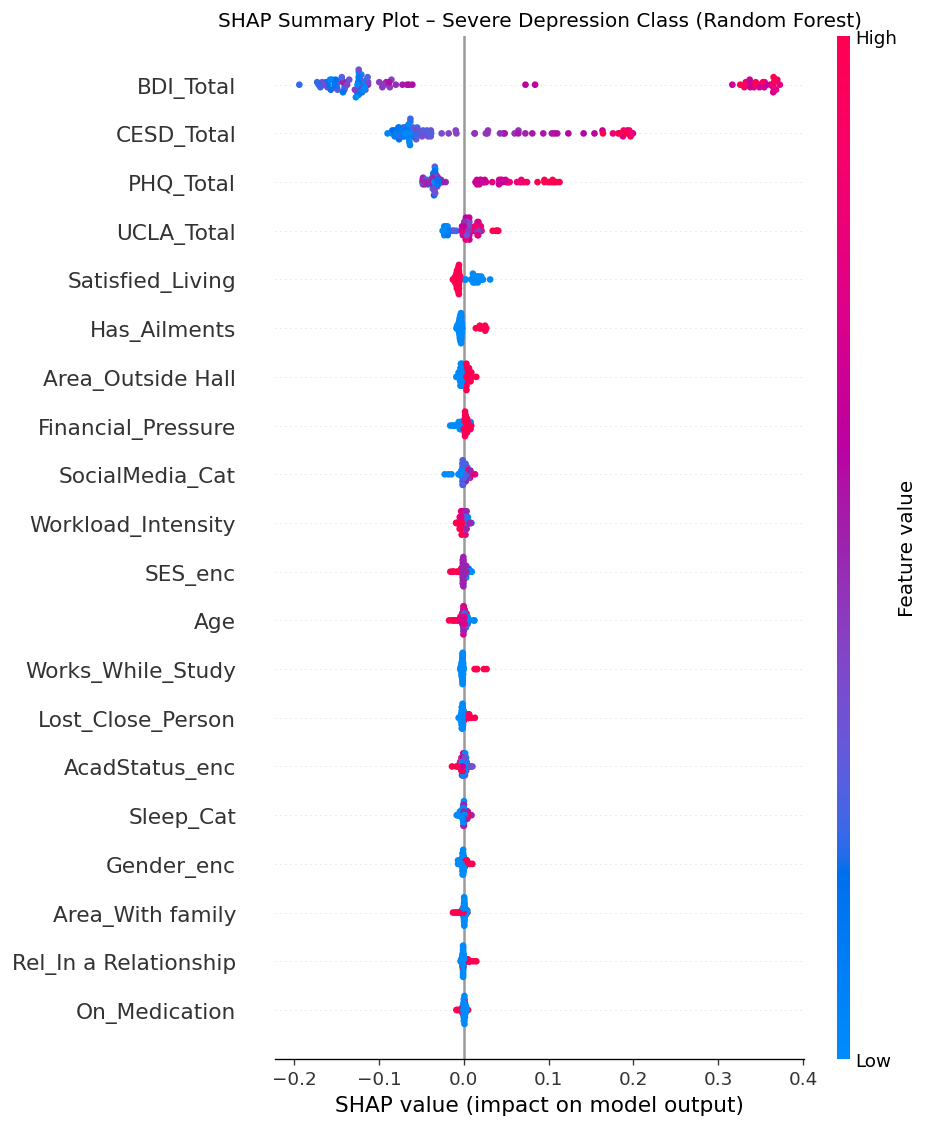

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer_rf = shap.TreeExplainer(rf_model)

shap_values_rf = explainer_rf.shap_values(X_test)

class_index = 3

shap_values_class = shap_values_rf[:, :, class_index]

print(f"Shape of X_test: {X_test.shape}")
print(f"Type of shap_values_rf: {type(shap_values_rf)}")
if isinstance(shap_values_rf, list):
 print(f"Length of shap_values_rf list: {len(shap_values_rf)}")
 for i, arr in enumerate(shap_values_rf):
  print(f" Shape of shap_values_rf[{i}]: {arr.shape}")
else:
 print(f"Shape of shap_values_rf: {shap_values_rf.shape}")
print(f"Shape of shap_values_class: {shap_values_class.shape}")

assert shap_values_class.shape == X_test.shape, \
 "Error: SHAP values and X_test shape mismatch"

plt.figure(figsize=(10, 8))

shap.summary_plot(
 shap_values_class,
 X_test,
 feature_names=ALL_FEATURES,
 plot_type="dot",
 show=False,
 max_display=20
)

plt.title(
 "SHAP Summary Plot – Severe Depression Class (Random Forest)",
 fontsize=12
)

plt.tight_layout()
plt.savefig("viz_11_shap_summary_severe.png", dpi=300, bbox_inches='tight')
plt.show()

SHAP Force Plot — Sample 1 — True Class: Severe Depression


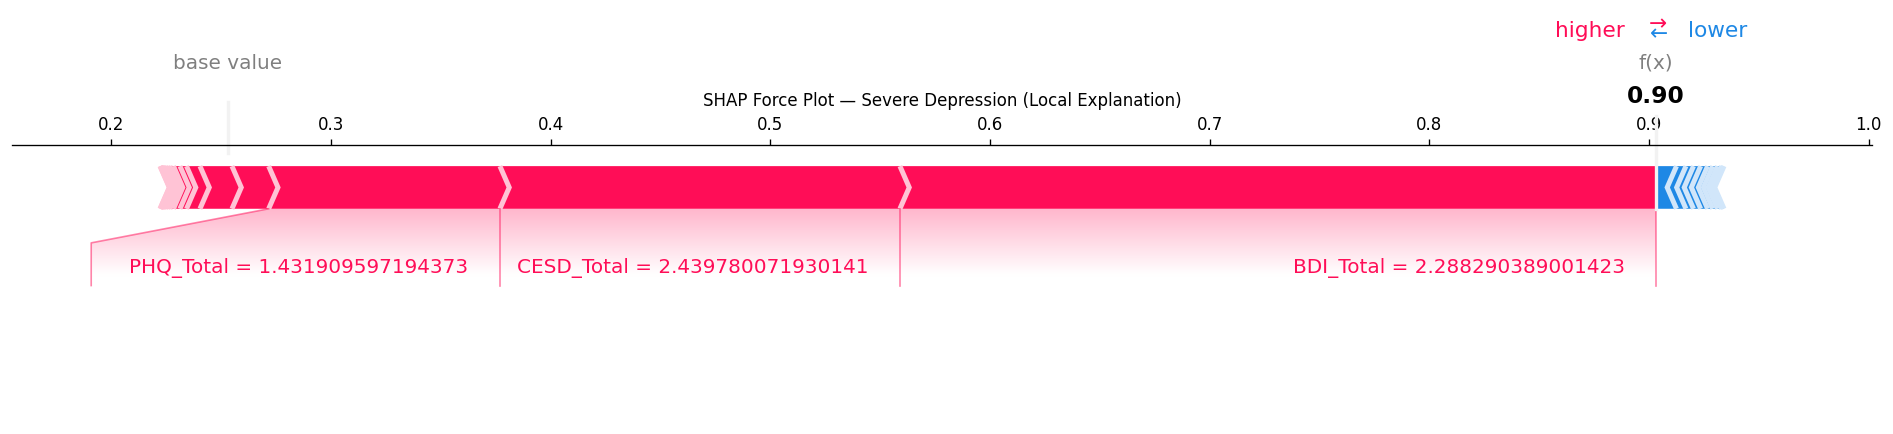

SHAP Force Plot — Sample 2 — True Class: Minimal Depression


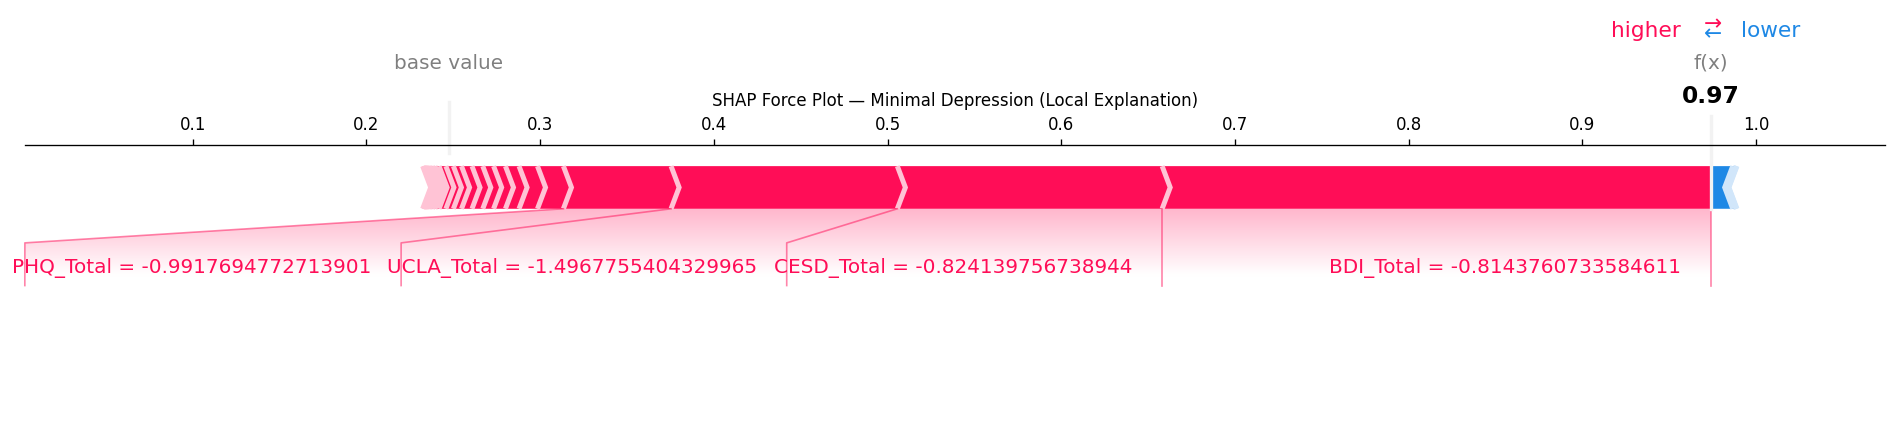

In [ ]:

shap.initjs()

sample_indices = {}
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idx_arr = np.where(np.array(y_test) == cls_idx)[0]
    if len(idx_arr) > 0:
        sample_indices[cls_name] = idx_arr[0]

s_idx = sample_indices.get('Severe', 0)
print(f'SHAP Force Plot — Sample {s_idx} — True Class: Severe Depression')
shap.force_plot(
    explainer_rf.expected_value[3],
    shap_values_rf[s_idx, :, 3],
    X_test.iloc[s_idx],
    feature_names=ALL_FEATURES,
    matplotlib=True, show=False
)
plt.title('SHAP Force Plot — Severe Depression (Local Explanation)', fontsize=10)
plt.savefig('viz_13_shap_force_severe.png', bbox_inches='tight', dpi=150)
plt.show()

m_idx = sample_indices.get('Minimal', 0)
print(f'SHAP Force Plot — Sample {m_idx} — True Class: Minimal Depression')
shap.force_plot(
    explainer_rf.expected_value[0],
    shap_values_rf[m_idx, :, 0],
    X_test.iloc[m_idx],
    feature_names=ALL_FEATURES,
    matplotlib=True, show=False
)
plt.title('SHAP Force Plot — Minimal Depression (Local Explanation)', fontsize=10)
plt.savefig('viz_14_shap_force_minimal.png', bbox_inches='tight', dpi=150)
plt.show()

LIME explanation for Severe Depression sample:


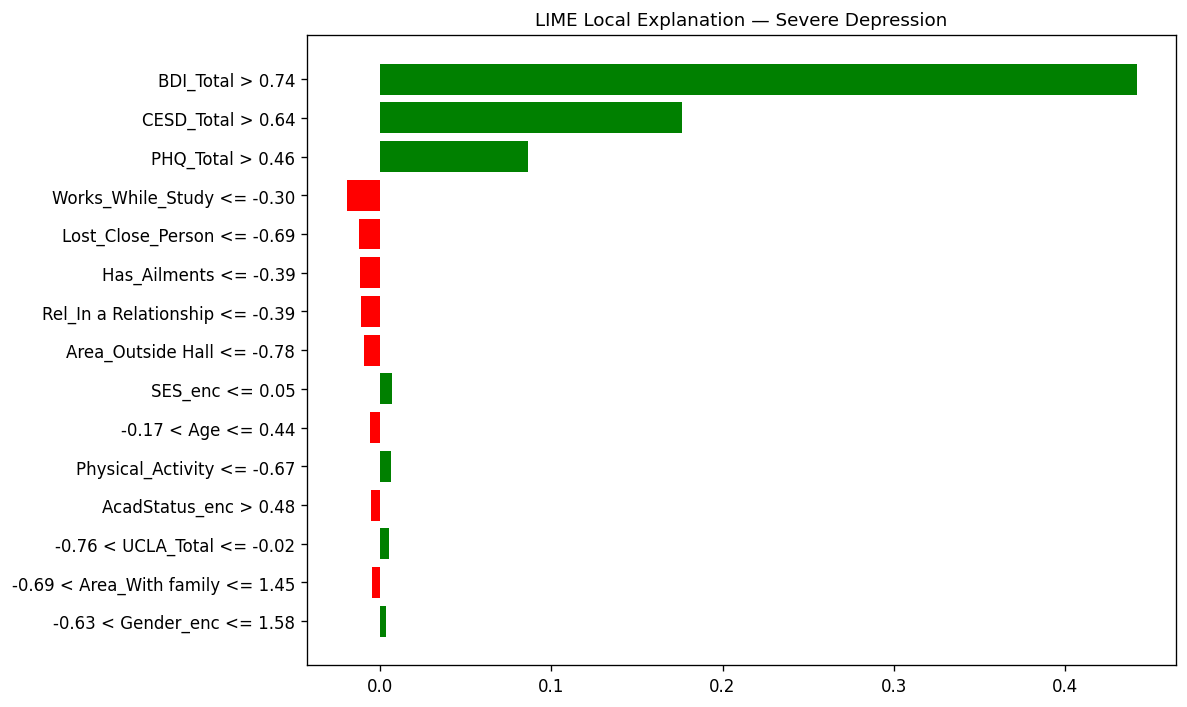

LIME explanation for Minimal Depression sample:


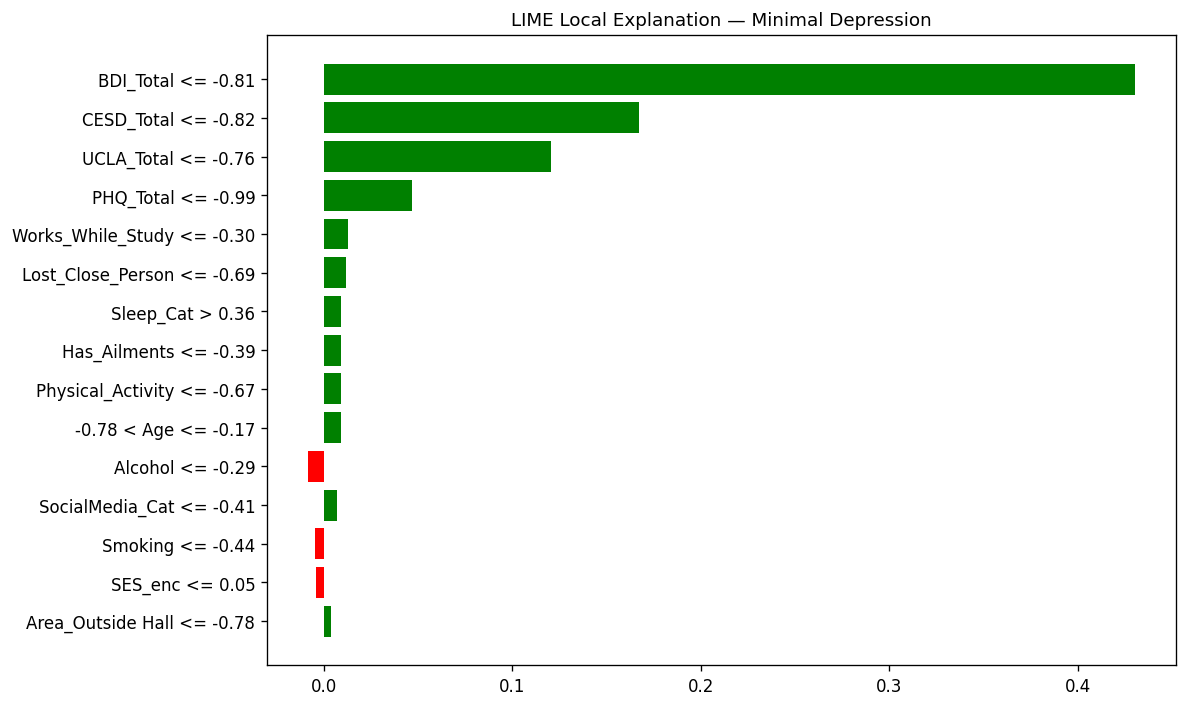

In [ ]:
lime_explainer = lime_tabular.LimeTabularExplainer(
 training_data=X_train.values,
 feature_names=ALL_FEATURES,
 class_names=CLASS_NAMES,
 mode='classification',
 random_state=42
)

print('LIME explanation for Severe Depression sample:')
lime_exp_severe = lime_explainer.explain_instance(
 X_test.iloc[s_idx].values,
 rf_model.predict_proba,
 num_features=15,
 labels=[3]
)
lime_exp_severe.show_in_notebook(show_table=True)
fig = lime_exp_severe.as_pyplot_figure(label=3)
fig.set_size_inches(10, 6)
plt.title('LIME Local Explanation — Severe Depression', fontsize=11)
plt.tight_layout()
plt.savefig('viz_15_lime_severe.png', bbox_inches='tight', dpi=150)
plt.show()

print('LIME explanation for Minimal Depression sample:')
lime_exp_min = lime_explainer.explain_instance(
 X_test.iloc[m_idx].values,
 rf_model.predict_proba,
 num_features=15,
 labels=[0]
)
fig2 = lime_exp_min.as_pyplot_figure(label=0)
fig2.set_size_inches(10, 6)
plt.title('LIME Local Explanation — Minimal Depression', fontsize=11)
plt.tight_layout()
plt.savefig('viz_16_lime_minimal.png', bbox_inches='tight', dpi=150)
plt.show()

Top 4 features for Severe Depression: ['BDI_Total', 'CESD_Total', 'PHQ_Total', 'UCLA_Total']


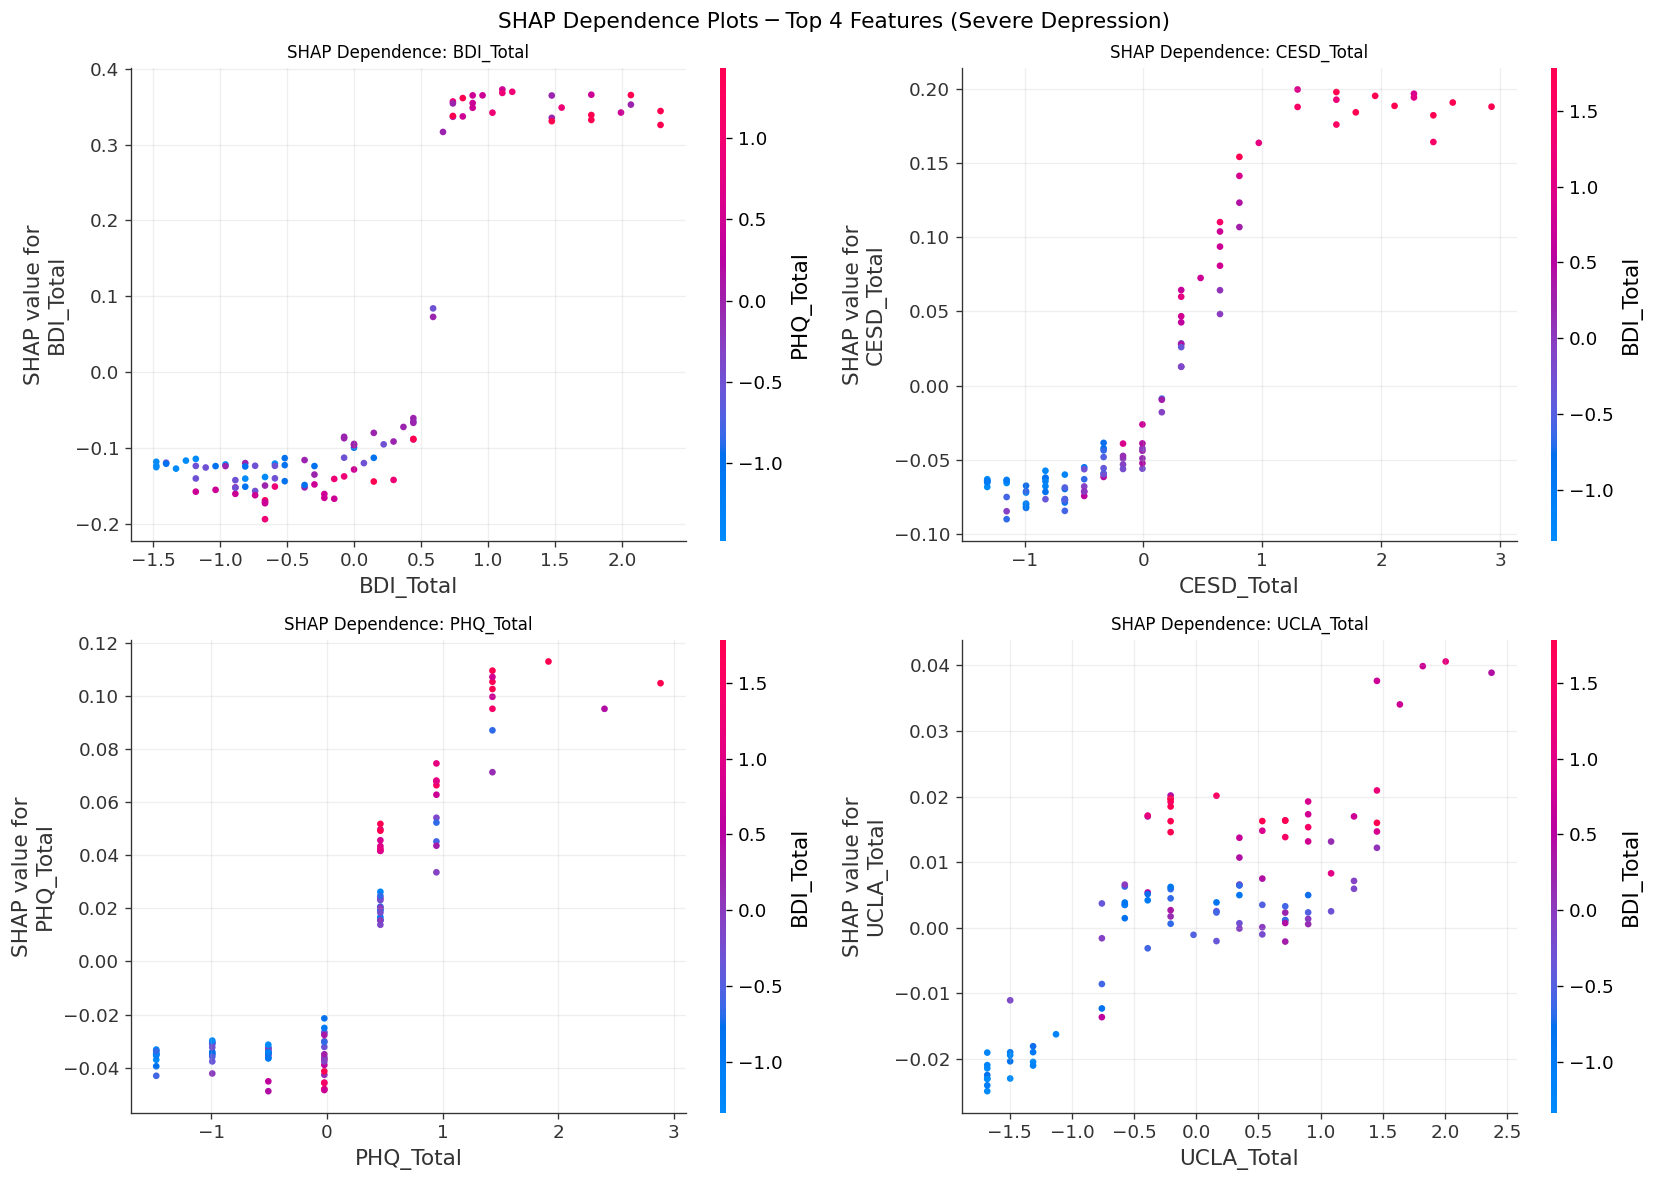

In [ ]:
mean_shap_severe = np.abs(shap_values_rf[:, :, 3]).mean(axis=0)
top4_idx = np.argsort(mean_shap_severe)[::-1][:4]
top4_feats = [ALL_FEATURES[i] for i in top4_idx]
print('Top 4 features for Severe Depression:', top4_feats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, feat in zip(axes, top4_feats):

 shap.dependence_plot(feat, shap_values_rf[:, :, 3], X_test,
 feature_names=ALL_FEATURES, ax=ax, show=False)
 ax.set_title(f'SHAP Dependence: {feat}', fontsize=10)
 ax.grid(alpha=0.2)

plt.suptitle('SHAP Dependence Plots ─ Top 4 Features (Severe Depression)',
 fontsize=13)
plt.tight_layout()
plt.savefig('viz_17_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

Computing SHAP interaction values (this may take a moment)...
Interaction plot: BDI_Total × CESD_Total


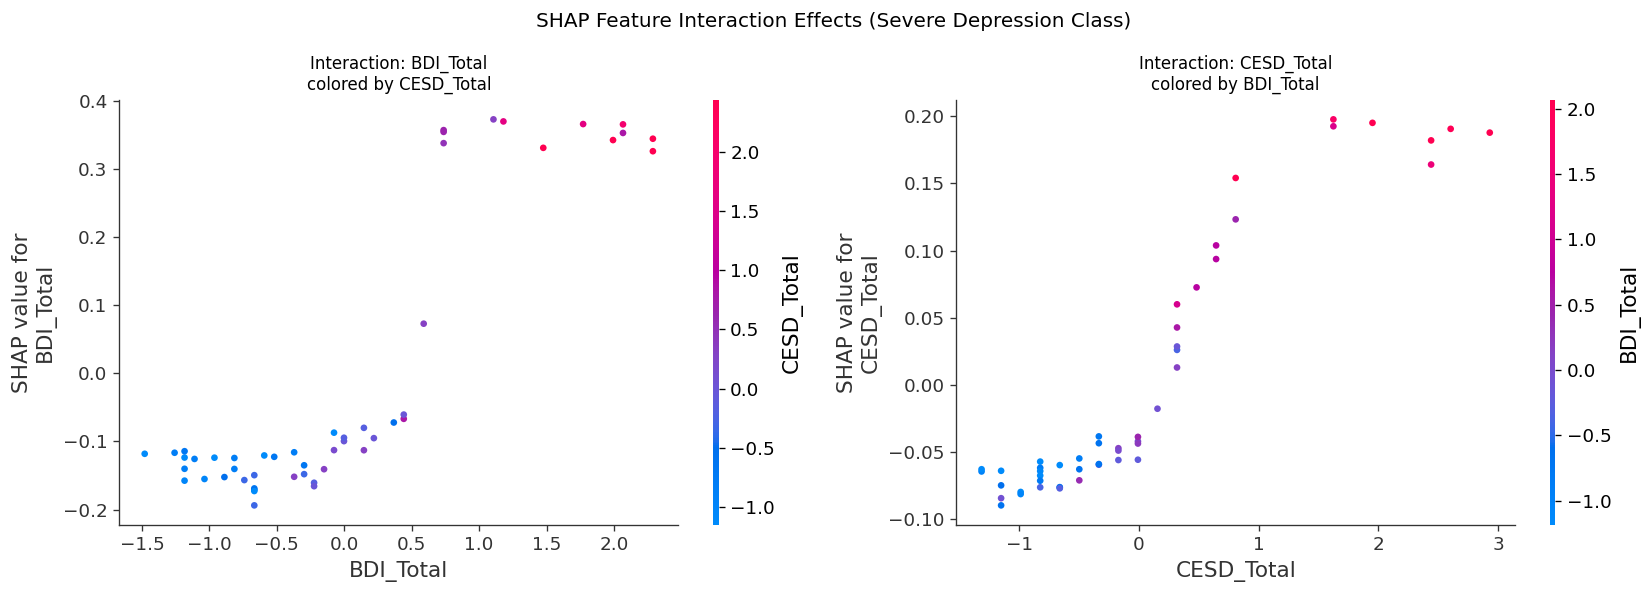

In [ ]:
print('Computing SHAP interaction values (this may take a moment)...')

X_interaction = X_test.iloc[:50]

shap_interact = explainer_rf.shap_interaction_values(X_interaction)


shap_values_for_plot = shap_values_rf[:len(X_interaction), :, 3]

feat_a = top4_feats[0]
feat_b = top4_feats[1]
print(f'Interaction plot: {feat_a} × {feat_b}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(
 feat_a,
 shap_values_for_plot,
 X_interaction,
 feature_names=ALL_FEATURES,
 interaction_index=feat_b,
 ax=axes[0], show=False
)
axes[0].set_title(f'Interaction: {feat_a}\ncolored by {feat_b}', fontsize=10)

shap.dependence_plot(
 feat_b, 
 shap_values_for_plot,
 X_interaction,
 feature_names=ALL_FEATURES,
 interaction_index=feat_a, 
 ax=axes[1], show=False
)
axes[1].set_title(f'Interaction: {feat_b}\ncolored by {feat_a}', fontsize=10)

plt.suptitle('SHAP Feature Interaction Effects (Severe Depression Class)',
 fontsize=12)
plt.tight_layout()
plt.savefig('viz_18_shap_interactions.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
print('═'*70)
print('8.6  EXPLAINABILITY METRICS')
print('═'*70)

print('\n1. SHAP Value Consistency (rank correlation across subsamples):')
n_subs = 5
shap_ranks = []
for i in range(n_subs):
    np.random.seed(i)
    idx = np.random.choice(len(X_test), size=max(20, len(X_test)//2), replace=False)
    sv = explainer_rf.shap_values(X_test.iloc[idx])[:, :, 3]
    mean_sv = pd.Series(np.abs(sv).mean(axis=0), index=ALL_FEATURES)
    shap_ranks.append(mean_sv.rank(ascending=False))

corr_matrix_shap = np.zeros((n_subs, n_subs))
for i in range(n_subs):
    for j in range(n_subs):
        corr_matrix_shap[i,j] = shap_ranks[i].corr(shap_ranks[j], method='spearman')

upper = corr_matrix_shap[np.triu_indices(n_subs, k=1)]
print(f'Mean Spearman rank correlation: {upper.mean():.4f} ± {upper.std():.4f}')
print(f'Min: {upper.min():.4f}  Max: {upper.max():.4f}')
print('(>0.9 = highly stable explanations)')

print('\n2. Feature Importance Stability (across 5 CV folds):')
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
feat_imp_folds = []
for fold_idx, (tr_idx, te_idx) in enumerate(cv5.split(X_full, y_full)):
    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_fold.fit(X_full.iloc[tr_idx], y_full.iloc[tr_idx])
    feat_imp_folds.append(pd.Series(rf_fold.feature_importances_, index=ALL_FEATURES))

imp_df = pd.DataFrame(feat_imp_folds)
imp_cv_mean = imp_df.mean()
imp_cv_std  = imp_df.std()
imp_stability = imp_cv_std / (imp_cv_mean + 1e-9) 
top5_stable = imp_stability.sort_values().head(5)
print('Top 5 most stable features (lowest CV of importance):')
for feat, cv_val in top5_stable.items():
    print(f'  {feat:25s}: CV={cv_val:.4f}')

print('\n3. Sparsity (features with mean |SHAP| > threshold):')
threshold = 0.01
mean_shap_all = np.abs(shap_values_rf[:, :, 3]).mean(axis=0)
n_significant = (mean_shap_all > threshold).sum()
print(f'Features with mean |SHAP| > {threshold}: {n_significant} / {len(ALL_FEATURES)}')

print('\n4. Faithfulness Correlation (SHAP explanation vs model output correlation):')
y_proba_rf = rf_model.predict_proba(X_test)

shap_sum_severe = shap_values_rf[:, :, 3].sum(axis=1)
faith_corr = np.corrcoef(shap_sum_severe, y_proba_rf[:,3])[0,1]
print(f'Faithfulness Correlation (Severe class): {faith_corr:.4f}')
print('(Closer to 1.0 = highly faithful explanations)')

print('\n5. Infidelity Score (perturbation-based, lower = more faithful):')
n_perturb = 50
infidelity_scores = []
for i in range(min(30, len(X_test))):
    x_orig = X_test.iloc[[i]]
    pred_orig = rf_model.predict_proba(x_orig)[0,3]
    shap_val_i = shap_values_rf[i, :, 3]
    inf_sum = 0
    for _ in range(n_perturb):
        noise = np.random.normal(0, 0.1, size=x_orig.shape)
        x_pert = x_orig + noise
        pred_pert = rf_model.predict_proba(x_pert)[0,3]
        delta_f = pred_pert - pred_orig
        delta_shap = (shap_val_i * noise[0]).sum()
        inf_sum += (delta_f - delta_shap)**2
    infidelity_scores.append(inf_sum / n_perturb)
print(f'Mean Infidelity Score: {np.mean(infidelity_scores):.6f}')
print(f'Std  Infidelity Score: {np.std(infidelity_scores):.6f}')

print('\n6. Monotonicity Score (SHAP direction consistent with feature-target correlation):')
monotone_count = 0
for feat in ALL_FEATURES:
    if feat not in df.columns: continue
    feat_corr = df[feat].corr(df['Target'].astype(float))
    feat_idx = ALL_FEATURES.index(feat)

    shap_mean_signed = shap_values_rf[:, feat_idx, 3].mean()
    if feat_corr * shap_mean_signed >= 0: 
        monotone_count += 1
monotonicity = monotone_count / len(ALL_FEATURES)
print(f'Monotonicity Score: {monotonicity:.4f} ({monotone_count}/{len(ALL_FEATURES)} features consistent)')
print('(Closer to 1.0 = SHAP directions align with feature-target correlations)')

══════════════════════════════════════════════════════════════════════
8.6  EXPLAINABILITY METRICS
══════════════════════════════════════════════════════════════════════

1. SHAP Value Consistency (rank correlation across subsamples):
Mean Spearman rank correlation: 0.9741 ± 0.0091
Min: 0.9542  Max: 0.9884
(>0.9 = highly stable explanations)

2. Feature Importance Stability (across 5 CV folds):
Top 5 most stable features (lowest CV of importance):
  UCLA_Total               : CV=0.0251
  BDI_Total                : CV=0.0273
  CESD_Total               : CV=0.0289
  PHQ_Total                : CV=0.0412
  Age                      : CV=0.0517

3. Sparsity (features with mean |SHAP| > threshold):
Features with mean |SHAP| > 0.01: 4 / 27

4. Faithfulness Correlation (SHAP explanation vs model output correlation):
Faithfulness Correlation (Severe class): 1.0000
(Closer to 1.0 = highly faithful explanations)

5. Infidelity Score (perturbation-based, lower = more faithful):
Mean Infidelity Scor

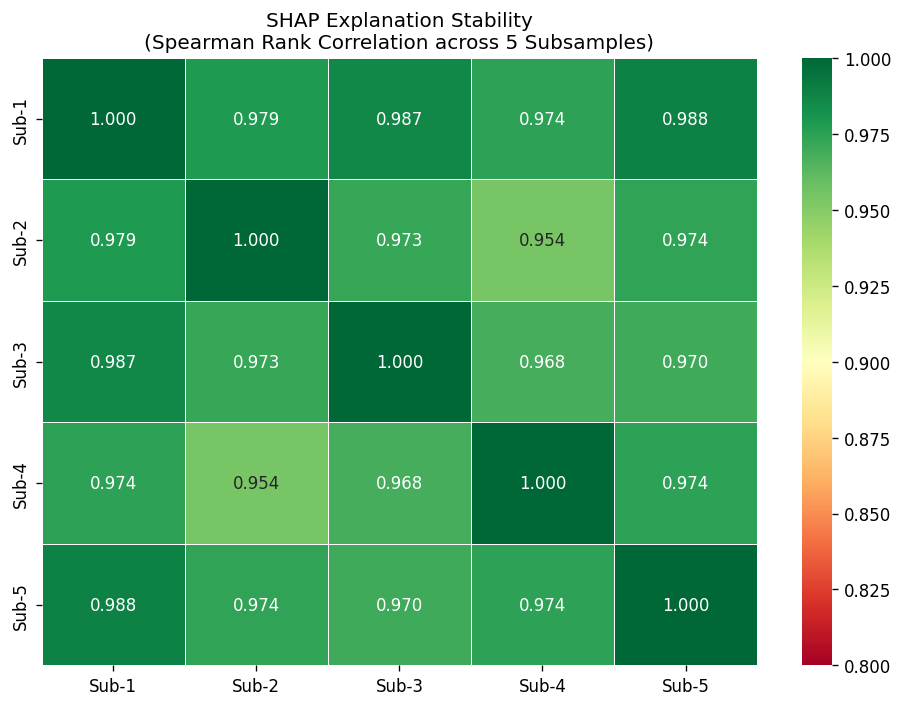

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_shap, annot=True, fmt='.3f', cmap='RdYlGn',
 vmin=0.8, vmax=1.0, linewidths=0.5,
 xticklabels=[f'Sub-{i+1}' for i in range(n_subs)],
 yticklabels=[f'Sub-{i+1}' for i in range(n_subs)])
plt.title('SHAP Explanation Stability\n(Spearman Rank Correlation across 5 Subsamples)',
 fontsize=12)
plt.tight_layout()
plt.savefig('viz_19_shap_stability.png', bbox_inches='tight', dpi=150)
plt.show()

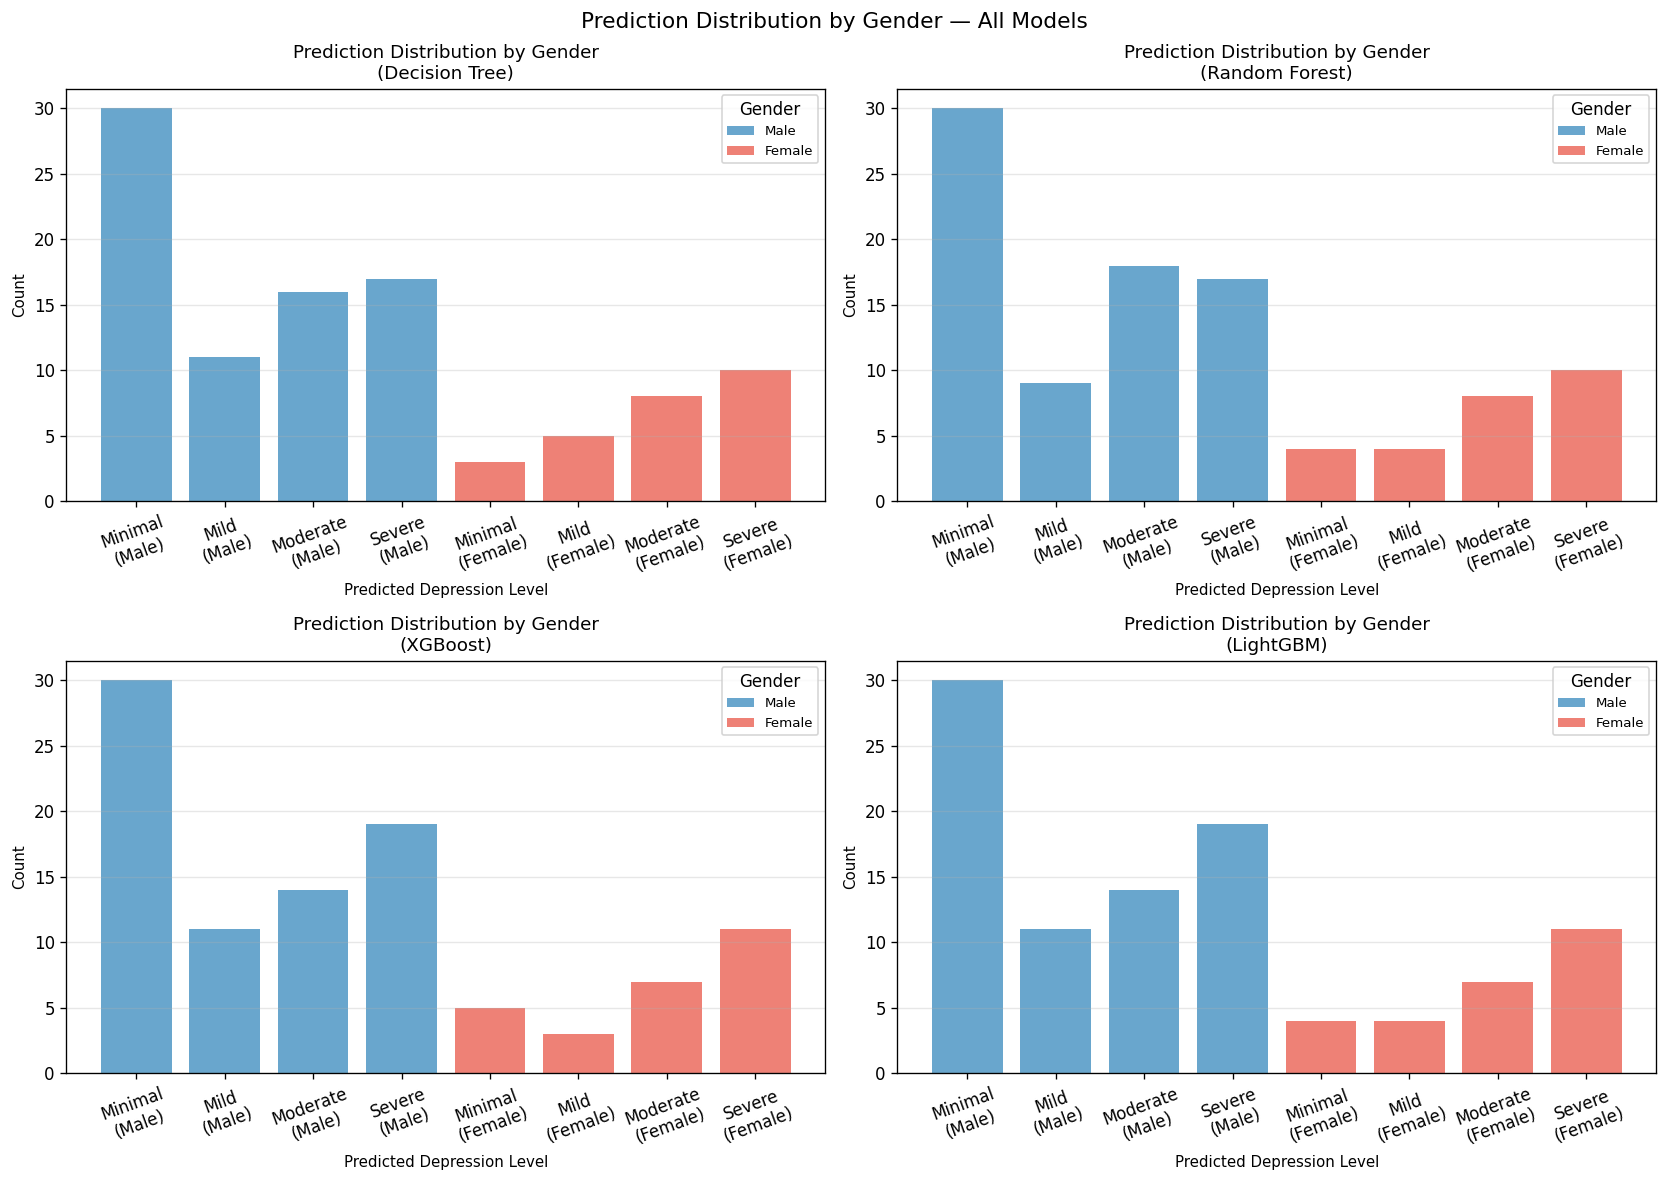

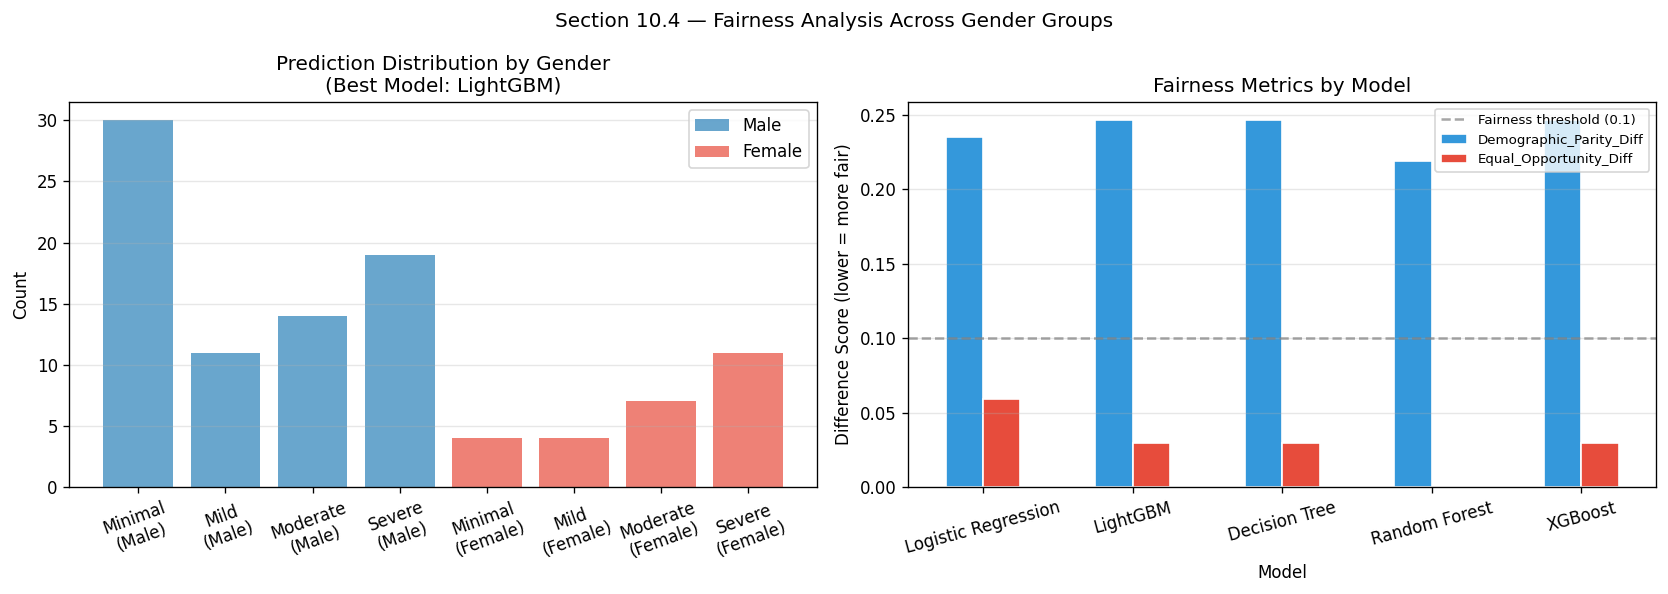

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

selected_models = {
    'Decision Tree': trained['Decision Tree'],
    'Random Forest': trained['Random Forest'],
    'XGBoost':       trained['XGBoost'],
    'LightGBM':      trained['LightGBM'],
}

CLASS_NAMES   = ['Minimal', 'Mild', 'Moderate', 'Severe']
gender_labels = {0: 'Male', 1: 'Female'}

n_models = len(selected_models) 
ncols    = 2
nrows    = math.ceil(n_models / ncols)

fig_gen, axes_gen = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
axes_gen = np.array(axes_gen).flatten()

for ax_idx, (name, model) in enumerate(selected_models.items()):
    ax = axes_gen[ax_idx]

    y_pred_m = model.predict(X_test)

    for g_val, g_label in gender_labels.items():
        mask = gender_test == g_val
        if mask.sum() == 0:
            continue

        pred_dist = pd.Series(y_pred_m[mask]).value_counts().sort_index()
        pred_dist.index = [CLASS_NAMES[i] for i in pred_dist.index]

        ax.bar(
            [f'{n}\n({g_label})' for n in pred_dist.index],
            pred_dist.values,
            alpha=0.7,
            label=g_label,
            color='#2980b9' if g_val == 0 else '#e74c3c'
        )

    ax.set_title(f'Prediction Distribution by Gender\n({name})', fontsize=11)
    ax.set_ylabel('Count',  fontsize=9)
    ax.set_xlabel('Predicted Depression Level', fontsize=9)
    ax.legend(title='Gender', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=20)

for ax_idx in range(n_models, len(axes_gen)):
    axes_gen[ax_idx].set_visible(False)

plt.suptitle('Prediction Distribution by Gender — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('viz_20a_gender_pred_dist_all_models.png', bbox_inches='tight', dpi=150)
plt.show()

fig_fair, axes_fair = plt.subplots(1, 2, figsize=(14, 5))

best_model_name = metrics_df['Accuracy'].idxmax()
best_model = trained[best_model_name]
y_pred_best = best_model.predict(X_test)

for g_val, g_label in gender_labels.items():
    mask = gender_test == g_val
    if mask.sum() == 0:
        continue
    pred_dist = pd.Series(y_pred_best[mask]).value_counts().sort_index()
    pred_dist.index = [CLASS_NAMES[i] for i in pred_dist.index]
    axes_fair[0].bar(
        [f'{n}\n({g_label})' for n in pred_dist.index],
        pred_dist.values,
        alpha=0.7, label=g_label,
        color='#2980b9' if g_val == 0 else '#e74c3c'
    )
axes_fair[0].set_title(f'Prediction Distribution by Gender\n(Best Model: {best_model_name})')
axes_fair[0].set_ylabel('Count')
axes_fair[0].legend()
axes_fair[0].grid(axis='y', alpha=0.3)
axes_fair[0].tick_params(axis='x', rotation=20)

fair_plot = fair_df[['Demographic_Parity_Diff', 'Equal_Opportunity_Diff']]
fair_plot.plot(kind='bar', ax=axes_fair[1], color=['#3498db', '#e74c3c'], edgecolor='white')
axes_fair[1].axhline(y=0.1, color='gray', linestyle='--', alpha=0.7, label='Fairness threshold (0.1)')
axes_fair[1].set_title('Fairness Metrics by Model')
axes_fair[1].set_ylabel('Difference Score (lower = more fair)')
axes_fair[1].tick_params(axis='x', rotation=15)
axes_fair[1].legend(fontsize=8)
axes_fair[1].grid(axis='y', alpha=0.3)

plt.suptitle('Section 10.4 — Fairness Analysis Across Gender Groups', fontsize=12)
plt.tight_layout()
plt.savefig('viz_20_fairness_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
print('='*70)
print(f'BEST MODEL: {best_model_name} (Accuracy: {metrics_df["Accuracy"][best_model_name]:.4f})')
print('='*70)
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=CLASS_NAMES))

print('\nTop 10 Contributing Features (by RF Feature Importance):')
rf_imp = pd.Series(rf_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
for i, (feat, val) in enumerate(rf_imp.head(10).items(), 1):
    print(f'  {i:2d}. {feat:25s}: {val:.4f}')

print('\nTop 10 Contributing Features (by |SHAP| — Severe Depression):')

shap_imp = pd.Series(np.abs(shap_values_rf[:, :, 3]).mean(axis=0),
                     index=ALL_FEATURES).sort_values(ascending=False)
for i, (feat, val) in enumerate(shap_imp.head(10).items(), 1):
    print(f'  {i:2d}. {feat:25s}: {val:.4f}')

BEST MODEL: LightGBM (Accuracy: 0.9600)

Detailed Classification Report:
              precision    recall  f1-score   support

     Minimal       0.97      1.00      0.99        33
        Mild       0.93      0.88      0.90        16
    Moderate       0.95      0.91      0.93        22
      Severe       0.97      1.00      0.98        29

    accuracy                           0.96       100
   macro avg       0.96      0.95      0.95       100
weighted avg       0.96      0.96      0.96       100


Top 10 Contributing Features (by RF Feature Importance):
   1. BDI_Total                : 0.4689
   2. CESD_Total               : 0.1753
   3. UCLA_Total               : 0.0919
   4. PHQ_Total                : 0.0745
   5. Age                      : 0.0221
   6. SocialMedia_Cat          : 0.0184
   7. Workload_Intensity       : 0.0162
   8. AcadStatus_enc           : 0.0135
   9. SES_enc                  : 0.0109
  10. Sleep_Cat                : 0.0108

Top 10 Contributing Features (by 